# Analiza wyników - wykresy do rozdziału 3

In [36]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


RESULTS_DIR = Path('../results')
SEEDS = [29, 81]

AGG_DIR = RESULTS_DIR / f'aggregation_seeds_{"_".join(map(str, SEEDS))}'
FIG_DIR = AGG_DIR / 'notebook_figs' / 'new_2seeds'
FIG_DIR.mkdir(parents=True, exist_ok=True)


DATASETS = ['CICIDS', 'UNSW_NB15']

DATASET_LABELS = {
    'CICIDS': 'CICIDS 2017',
    'UNSW_NB15': 'UNSW-NB15',
}

DATASET_SUFFIX = {
    'CICIDS': 'cicids',
    'UNSW_NB15': 'unsw',
}

COLORS = list(plt.cm.Set2.colors)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'font.size': 10,
    'savefig.dpi': 300,
    'legend.frameon': False,
})


RUN_NAME_TO_INDEX = {
    '1st': 1,
    '2nd': 2,
    '3rd': 3,
}


def extract_run_index_from_filename(filename):
    """
    Odczytuje numer runu z nazwy pliku JSON.

    Przykłady:
    1st_run_IsolationForest_CICIDS.json -> 1
    2nd_run_LOF_UNSW_NB15.json          -> 2
    3rd_run_LUNAR_CICIDS.json           -> 3
    """
    match = re.match(
        r'^(1st|2nd|3rd)_run_',
        Path(filename).name,
        flags=re.IGNORECASE,
    )

    if match is None:
        return pd.NA

    return RUN_NAME_TO_INDEX[match.group(1).lower()]


def flatten_confusion_matrix(record):
    """
    Rozbija macierz pomyłek [[TN, FP], [FN, TP]]
    na osobne kolumny.
    """
    matrix = record.get('ConfusionMatrix')

    if (
        isinstance(matrix, list)
        and len(matrix) == 2
        and all(
            isinstance(row, list) and len(row) == 2
            for row in matrix
        )
    ):
        record['ConfusionMatrix_TN'] = matrix[0][0]
        record['ConfusionMatrix_FP'] = matrix[0][1]
        record['ConfusionMatrix_FN'] = matrix[1][0]
        record['ConfusionMatrix_TP'] = matrix[1][1]

    return record


def load_raw_json_results(results_dir, seeds):
    """
    Wczytuje surowe pliki JSON z katalogów:
    results/seed_29/
    results/seed_81/

    Pomija katalog aggregation i wykorzystuje tylko pliki,
    których nazwa zaczyna się od:
    - 1st_run_
    - 2nd_run_
    - 3rd_run_

    Każdy rekord otrzymuje:
    - seed,
    - run_index,
    - source_file,
    - source_path,
    - threshold_variant = standard.
    """
    rows = []

    for seed in seeds:
        seed_dir = Path(results_dir) / f'seed_{seed}'

        if not seed_dir.exists():
            print(f'UWAGA: nie znaleziono katalogu: {seed_dir}')
            continue

        json_files = sorted(seed_dir.rglob('*.json'))

        for json_path in json_files:
            relative_parts = json_path.relative_to(seed_dir).parts

            if 'aggregation' in relative_parts:
                continue

            run_index = extract_run_index_from_filename(
                json_path.name
            )

            if pd.isna(run_index):
                continue

            try:
                with open(
                    json_path,
                    'r',
                    encoding='utf-8',
                ) as file:
                    record = json.load(file)

            except (
                json.JSONDecodeError,
                UnicodeDecodeError,
            ) as exc:
                print(
                    f'UWAGA: pominięto {json_path.name}: {exc}'
                )
                continue

            if not isinstance(record, dict):
                print(
                    f'UWAGA: plik {json_path.name} '
                    f'nie zawiera obiektu JSON'
                )
                continue

            record = flatten_confusion_matrix(
                record.copy()
            )

            record['seed'] = int(
                record.get('seed', seed)
            )

            record['run_index'] = int(run_index)
            record['source_file'] = json_path.name
            record['source_path'] = str(json_path)
            record['threshold_variant'] = 'standard'

            rows.append(record)

    if not rows:
        raise RuntimeError(
            'Nie znaleziono żadnych surowych plików JSON '
            'dla wskazanych seedów.'
        )

    raw_df = pd.json_normalize(rows)

    raw_df['seed'] = pd.to_numeric(
        raw_df['seed'],
        errors='coerce',
    ).astype('Int64')

    raw_df['run_index'] = pd.to_numeric(
        raw_df['run_index'],
        errors='coerce',
    ).astype('Int64')

    numeric_metrics = [
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'Recall_at_FPR_0.01',
        'Precision_at_Recall_0.80',
        'runtime_train',
        'runtime_inference',
        'ConfusionMatrix_TN',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_FN',
        'ConfusionMatrix_TP',
    ]

    for metric in numeric_metrics:
        if metric in raw_df.columns:
            raw_df[metric] = pd.to_numeric(
                raw_df[metric],
                errors='coerce',
            )

    return raw_df


df = load_raw_json_results(RESULTS_DIR, SEEDS)

print(
    f'Wczytano {len(df)} surowych rekordów JSON '
    f'z seedów: {sorted(df["seed"].dropna().unique())}'
)

print('\nLiczba rekordów według seeda:')
print(df['seed'].value_counts().sort_index())

print('\nLiczba rekordów według run_index:')
print(df['run_index'].value_counts().sort_index())

print('\nKontrola liczby rekordów seed × run_index:')
display(
    pd.crosstab(
        df['run_index'],
        df['seed'],
        margins=True,
    )
)


df_std = df.copy()


def no_perturbation_mask(frame):
    """
    Zwraca maskę dla wyników bez zaburzeń:
    - bez dropout cech,
    - bez zmiany proporcji ataków,
    - bez dodanego szumu.
    """
    mask = pd.Series(
        True,
        index=frame.index,
    )

    for col in [
        'hyperparameters.feature_dropout',
        'hyperparameters.imbalance_factor_test',
        'hyperparameters.noise',
    ]:
        if col in frame.columns:
            mask &= (
                frame[col].isna()
                | frame[col].eq(0)
            )

    return mask


df_std_clean = df_std[
    no_perturbation_mask(df_std)
].copy()


def norm(value):
    """
    Ujednolica tekst do porównań nazw modeli i strategii.
    """
    return re.sub(
        r'[^a-z0-9]+',
        '',
        str(value).lower(),
    )


def select(frame, dataset=None, model=None, fusion=None):
    """
    Filtruje dane według zbioru, modelu i strategii fuzji.

    Jeśli fusion=None, nie filtruje po fusion_strategy.
    """
    out = frame.copy()

    if dataset is not None:
        out = out[
            out['dataset_name'].eq(dataset)
        ]

    if model is not None:
        out = out[
            out['model_type']
            .map(norm)
            .eq(norm(model))
        ]

    if fusion is not None:
        if 'fusion_strategy' not in out.columns:
            return out.iloc[0:0]

        out = out[
            out['fusion_strategy']
            .fillna('')
            .map(norm)
            .eq(norm(fusion))
        ]

    return out


def agg(
    frame,
    mask,
    metrics=(
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'runtime_train',
        'runtime_inference',
        'ConfusionMatrix_TP',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_TN',
        'ConfusionMatrix_FN',
    ),
):
    """
    Prosta agregacja wszystkich rekordów spełniających maskę.
    Zachowana dla wcześniejszych fragmentów notebooka.
    """
    sub = frame.loc[mask]

    out = {
        'n': len(sub),
    }

    for metric in metrics:
        if metric in sub.columns:
            out[f'{metric}_mean'] = sub[metric].mean()
            out[f'{metric}_std'] = sub[metric].std()

    return out


def stats_for(frame):
    """
    Zwraca średnią i odchylenie standardowe ze wszystkich rekordów.

    Używaj tylko dla starszych tabel, które nie są
    rozdzielane według run_index.
    """
    metrics = [
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'runtime_train',
        'runtime_inference',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_FN',
    ]

    return {
        metric: (
            frame[metric].mean(),
            frame[metric].std(),
        )
        if metric in frame.columns
        else (np.nan, np.nan)
        for metric in metrics
    }


def pm(mean, std, nd=3):
    """
    Formatowanie średniej i odchylenia standardowego.
    """
    if pd.isna(mean):
        return '--'

    if pd.isna(std):
        return f'{mean:.{nd}f}'

    return f'{mean:.{nd}f} ± {std:.{nd}f}'


def pm_n(mean, std, n, nd=3):
    """
    Formatowanie średniej i SD.

    Parametr n służy wyłącznie do obsługi sytuacji,
    gdy nie ma pełnych danych dla dwóch seedów.
    Nie dodaje n do tekstu metryki.
    """
    if pd.isna(mean):
        return '--'

    if pd.isna(std) or n <= 1:
        return f'{mean:.{nd}f}'

    return f'{mean:.{nd}f} ± {std:.{nd}f}'


def stats_for_by(
    frame,
    groupby_col,
    fixed_col=None,
    fixed_val=None,
):
    """
    Agreguje metryki przez średnie per grupa.
    Zachowana dla starszych tabel notebooka.
    """
    sub = frame.copy()

    if fixed_col is not None:
        sub = sub[
            sub[fixed_col].eq(fixed_val)
        ]

    report_metrics = [
        'AUC_ROC',
        'AUC_PR',
        'Precision',
        'Recall',
        'F1',
        'runtime_train',
        'runtime_inference',
    ]

    if groupby_col not in sub.columns:
        return {
            metric: (np.nan, np.nan, 0)
            for metric in report_metrics
        }

    per_group = sub.groupby(
        groupby_col,
        dropna=False,
    )

    out = {}

    for metric in report_metrics:
        if metric not in sub.columns:
            out[metric] = (
                np.nan,
                np.nan,
                0,
            )
            continue

        per_group_means = per_group[metric].mean()

        out[metric] = (
            per_group_means.mean(),
            per_group_means.std(),
            len(per_group_means),
        )

    return out


RUN_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
    'Recall_at_FPR_0.01',
    'Precision_at_Recall_0.80',
    'runtime_train',
    'runtime_inference',
    'ConfusionMatrix_FP',
    'ConfusionMatrix_FN',
]


def seed_stats_for_run(frame, metrics=RUN_METRICS):
    """
    Agreguje wyniki tego samego run_index wyłącznie między seedami.

    Procedura:
    1. Dla danego seeda liczy średnią metryki, jeśli istnieje
       więcej niż jeden rekord dla tego samego wariantu.
    2. Liczy średnią wyników seedów.
    3. Liczy odchylenie standardowe między seedami.

    Nie miesza wyników Run 1, Run 2 i Run 3.
    """
    out = {
        'n_seedów': frame['seed'].nunique(),
    }

    if frame.empty or 'seed' not in frame.columns:
        for metric in metrics:
            out[f'{metric}_mean'] = np.nan
            out[f'{metric}_std'] = np.nan

        return out

    for metric in metrics:
        if metric not in frame.columns:
            out[f'{metric}_mean'] = np.nan
            out[f'{metric}_std'] = np.nan
            continue

        seed_means = (
            frame
            .groupby('seed')[metric]
            .mean()
            .dropna()
        )

        out[f'{metric}_mean'] = seed_means.mean()
        out[f'{metric}_std'] = seed_means.std(ddof=1)

    return out


def run_index_seed_summary(
    frame,
    dataset=None,
    model=None,
    fusion=None,
    metrics=RUN_METRICS,
):
    """
    Tworzy tabelę z wynikami dla Run 1, Run 2 i Run 3.

    Każdy wiersz:
    - dotyczy jednego run_index;
    - zawiera średnią metryki między seedami;
    - zawiera odchylenie standardowe między seedami;
    - zawiera wyłącznie dwie dodatkowe kolumny:
      Run oraz n seedów.
    """
    sub = select(
        frame,
        dataset=dataset,
        model=model,
        fusion=fusion,
    ).copy()

    if sub.empty:
        return pd.DataFrame()

    if 'run_index' not in sub.columns:
        raise KeyError(
            'Brak kolumny run_index. '
            'Dane muszą pochodzić z load_raw_json_results().'
        )

    sub = sub[
        sub['run_index'].notna()
    ].copy()

    rows = []

    for run_idx, group in sub.groupby(
        'run_index',
        sort=True,
    ):
        stats = seed_stats_for_run(
            group,
            metrics=metrics,
        )

        row = {
            'Run': int(run_idx),
            'n seedów': stats['n_seedów'],
        }

        for metric in metrics:
            decimals = (
                1
                if metric in {
                    'runtime_train',
                    'runtime_inference',
                    'ConfusionMatrix_FP',
                    'ConfusionMatrix_FN',
                }
                else 3
            )

            row[metric] = pm_n(
                stats[f'{metric}_mean'],
                stats[f'{metric}_std'],
                stats['n_seedów'],
                nd=decimals,
            )

        rows.append(row)

    return pd.DataFrame(rows)


def savefig(fig, name):
    """
    Zapisuje wykres do PDF i PNG.
    """
    pdf_path = FIG_DIR / f'{name}.pdf'
    png_path = FIG_DIR / f'{name}.png'

    fig.savefig(
        pdf_path,
        bbox_inches='tight',
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches='tight',
    )

    print(
        f'Zapisano: {pdf_path.name} oraz {png_path.name}'
    )


def to_latex_math(cell):
    """
    Zamienia zapis liczbowy na format zgodny z LaTeX.
    """
    s = str(cell)

    if s.strip() in ('--', 'nan', ''):
        return '--'

    s = re.sub(
        r'(\d+)\.(\d+)',
        lambda match: (
            match.group(1)
            + '{,}'
            + match.group(2)
        ),
        s,
    )

    s = s.replace('±', r'\pm')

    return f'${s}$'


def export_table(rows, name, caption=None, label=None):
    """
    Wyświetla tabelę, zapisuje CSV i generuje plik .tex.

    Kolumny Run i n seedów traktowane są jako tekstowe,
    nie są otaczane znakami $...$.
    """
    table = pd.DataFrame(rows)

    display(table)

    table.to_csv(
        FIG_DIR / f'{name}.csv',
        index=False,
    )

    cols = list(table.columns)

    id_cols = [
        col
        for col in cols
        if col in (
            'Zbiór',
            'Model',
            'Wariant',
            'Liczba epok',
            'Run',
            'n seedów',
        )
    ]

    metric_cols = [
        col
        for col in cols
        if col not in id_cols
    ]

    align = (
        'l' * len(id_cols)
        + 'c' * len(metric_cols)
    )

    cap = (
        caption
        or name.replace(
            '_',
            ' ',
        ).replace(
            '-',
            ' ',
        ).capitalize()
    )

    lab = label or f'tab:{name}'

    lines = [
        r'\begin{table}[H]',
        r'\centering',
        rf'\caption{{{cap}}}',
        rf'\label{{{lab}}}',
        r'\resizebox{\textwidth}{!}{%',
        rf'\begin{{tabular}}{{{align}}}',
        r'\hline',
        ' & '.join(cols) + r' \\',
        r'\hline',
    ]

    group_col = (
        'Zbiór'
        if 'Zbiór' in cols
        else None
    )

    previous_group = None

    for _, row in table.iterrows():
        if (
            group_col is not None
            and previous_group is not None
            and row[group_col] != previous_group
        ):
            lines.append(r'\hline')

        cells = [
            str(row[col])
            if col in id_cols
            else to_latex_math(row[col])
            for col in cols
        ]

        lines.append(
            ' & '.join(cells) + r' \\'
        )

        if group_col is not None:
            previous_group = row[group_col]

    lines += [
        r'\hline',
        r'\end{tabular}}',
        r'\end{table}',
        '',
        r'Źródło: opracowanie własne.',
    ]

    tex = '\n'.join(lines)

    (FIG_DIR / f'{name}.tex').write_text(
        tex,
        encoding='utf-8',
    )

    print(tex)

    return table


def bar_by_dataset(
    specs,
    metric,
    stem,
    ylabel,
    title,
    source=None,
    yscale='linear',
):
    """
    Wykres zbiorczy: jeden słupek na model.

    Zachowany dla wykresów, które nie wymagają
    rozdzielenia według run_index.
    """
    if source is None:
        source = df_std_clean

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 7.5),
    )

    for ax, ds in zip(axes, DATASETS):
        means = []
        stds = []
        labels = []

        for model, fusion, label in specs:
            sub = select(
                source,
                dataset=ds,
                model=model,
                fusion=fusion,
            )

            means.append(
                sub[metric].mean()
                if metric in sub.columns
                and not sub.empty
                else np.nan
            )

            stds.append(
                sub[metric].std()
                if metric in sub.columns
                and not sub.empty
                else np.nan
            )

            labels.append(label)

        x = np.arange(len(labels))

        rects = ax.bar(
            x,
            means,
            yerr=stds,
            capsize=5,
            color=COLORS[:len(labels)],
            ecolor='#404040',
            alpha=0.9,
            error_kw={
                'elinewidth': 1.2,
                'capthick': 1.2,
            },
        )

        for rect, mean, std in zip(
            rects,
            means,
            stds,
        ):
            if pd.notna(mean):
                offset = (
                    (
                        std
                        if pd.notna(std)
                        else 0
                    )
                    + (
                        mean * 0.03
                        if yscale == 'log'
                        else 0.02
                    )
                )

                ax.text(
                    rect.get_x()
                    + rect.get_width() / 2.0,
                    mean + offset,
                    (
                        f'{mean:.3f}'
                        if yscale == 'linear'
                        else f'{mean:.1f}'
                    ),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                )

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=10,
        )

        ax.set_ylabel(
            ylabel,
            fontsize=10,
            labelpad=8,
        )

        ax.set_title(
            DATASET_LABELS[ds],
            fontsize=11,
            pad=10,
        )

        if yscale == 'log':
            ax.set_yscale('log')

        else:
            max_val = max(
                [
                    mean + (
                        std
                        if pd.notna(std)
                        else 0
                    )
                    for mean, std in zip(
                        means,
                        stds,
                    )
                    if pd.notna(mean)
                ],
                default=1,
            )

            ax.set_ylim(0, max_val * 1.15)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            which='both',
            linestyle='--',
            alpha=0.5,
            zorder=0,
        )

        ax.set_axisbelow(True)

    fig.suptitle(
        title,
        fontsize=12,
        y=0.99,
    )

    fig.tight_layout(h_pad=3.0)

    savefig(fig, stem)

    plt.show()


def bar_per_dataset(
    specs,
    metric,
    stem,
    ylabel,
    title,
    source=None,
    run_indices=(1, 2, 3),
):
    """
    Tworzy osobny wykres dla każdego zbioru danych.

    Każdy model jest reprezentowany przez trzy słupki:
    - Run 1,
    - Run 2,
    - Run 3.

    Wysokość słupka:
        średnia wartości metryki między seedami.

    Belka błędu:
        odchylenie standardowe między seedami.
    """
    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        metric,
    }

    missing_columns = (
        required_columns
        - set(source.columns)
    )

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(
                sorted(missing_columns)
            )
        )

    run_indices = list(run_indices)
    n_runs = len(run_indices)

    bar_width = 0.22

    offsets = (
        np.arange(n_runs)
        - (n_runs - 1) / 2
    ) * bar_width

    run_colors = COLORS[:n_runs]

    for ds in DATASETS:
        labels = [
            label
            for _, _, label in specs
        ]

        x = np.arange(len(labels))

        fig, ax = plt.subplots(
            figsize=(9.2, 5.0),
        )

        all_tops = []

        for run_position, run_index in enumerate(
            run_indices
        ):
            means = []
            stds = []

            for model, fusion, _ in specs:
                sub = select(
                    source,
                    dataset=ds,
                    model=model,
                    fusion=fusion,
                ).copy()

                sub = sub[
                    sub['run_index'].eq(run_index)
                ].copy()

                if sub.empty:
                    means.append(np.nan)
                    stds.append(np.nan)
                    continue

                per_seed = (
                    sub
                    .groupby('seed')[metric]
                    .mean()
                    .dropna()
                )

                means.append(per_seed.mean())
                stds.append(per_seed.std(ddof=1))

            stds_plot = [
                0.0
                if pd.isna(std)
                else std
                for std in stds
            ]

            positions = x + offsets[run_position]

            bars = ax.bar(
                positions,
                means,
                width=bar_width,
                yerr=stds_plot,
                capsize=4,
                color=run_colors[run_position],
                ecolor='#404040',
                alpha=0.90,
                edgecolor='none',
                error_kw={
                    'elinewidth': 1.1,
                    'capthick': 1.1,
                },
                label=f'Run {run_index}',
            )

            for bar, mean, std in zip(
                bars,
                means,
                stds,
            ):
                if pd.isna(mean):
                    continue

                std_for_label = (
                    0.0
                    if pd.isna(std)
                    else std
                )

                all_tops.append(
                    mean + std_for_label
                )

                ax.annotate(
                    f'{mean:.3f}',
                    xy=(
                        bar.get_x()
                        + bar.get_width() / 2.0,
                        mean + std_for_label,
                    ),
                    xytext=(0, 4),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=8.5,
                )

        max_top = max(all_tops, default=1.0)

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=10,
        )

        ax.set_ylabel(
            ylabel,
            fontsize=10,
            labelpad=8,
        )

        ax.set_title(
            f'{title} — {DATASET_LABELS[ds]}',
            fontsize=11.5,
            pad=12,
        )

        ax.set_ylim(0, max_top * 1.16)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            linestyle='--',
            alpha=0.45,
            zorder=0,
        )

        ax.set_axisbelow(True)

        ax.legend(
            title='Numer runu',
            loc='upper left',
            frameon=True,
            facecolor='white',
            edgecolor='#D0D0D0',
            fontsize=9,
            title_fontsize=9,
        )

        fig.tight_layout()

        output_name = (
            f'{stem}-'
            f'{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(fig, output_name)

        plt.show()


def bar_dual_metric_by_dataset(
    specs,
    metrics,
    metric_labels,
    stem,
    ylabel,
    title,
    source=None,
):
    """
    Tworzy osobny wykres z dwiema metrykami
    dla każdego zbioru danych.
    """
    if source is None:
        source = df_std_clean

    labels = [
        spec[2]
        for spec in specs
    ]

    width = 0.38
    x = np.arange(len(labels))

    for ds in DATASETS:
        fig, ax = plt.subplots(
            figsize=(7, 4.5),
        )

        dataset_values = []

        for j, (
            metric_name,
            metric_label,
        ) in enumerate(
            zip(metrics, metric_labels)
        ):
            values = []

            for model, fusion, _ in specs:
                sub = select(
                    source,
                    dataset=ds,
                    model=model,
                    fusion=fusion,
                )

                values.append(
                    sub[metric_name].mean()
                    if metric_name in sub.columns
                    and not sub.empty
                    else np.nan
                )

            dataset_values.extend(
                [
                    value
                    for value in values
                    if pd.notna(value)
                ]
            )

            rects = ax.bar(
                x + (j - 0.5) * width,
                values,
                width,
                label=metric_label,
                color=COLORS[j],
                alpha=0.9,
            )

            for rect, value in zip(
                rects,
                values,
            ):
                if pd.notna(value):
                    ax.annotate(
                        f'{value:.1f}',
                        xy=(
                            rect.get_x()
                            + rect.get_width() / 2.0,
                            rect.get_height(),
                        ),
                        xytext=(0, 4),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=8,
                    )

        max_val = max(
            dataset_values,
            default=1,
        )

        ax.set_title(
            f'{title} — {DATASET_LABELS[ds]}',
            fontsize=11,
            pad=12,
        )

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=0,
            fontsize=9.5,
        )

        ax.set_ylabel(
            ylabel,
            fontsize=10,
            labelpad=8,
        )

        ax.set_ylim(0, max_val * 1.25)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)

        ax.yaxis.grid(
            True,
            linestyle='--',
            alpha=0.5,
            zorder=0,
        )

        ax.set_axisbelow(True)

        ax.legend(
            loc='upper center',
            ncol=2,
            frameon=True,
            facecolor='white',
            edgecolor='none',
            fontsize=9.5,
        )

        fig.tight_layout()

        savefig(
            fig,
            f'{stem}-'
            f'{DATASET_SUFFIX.get(ds, norm(ds))}',
        )

        plt.show()

Wczytano 642 surowych rekordów JSON z seedów: [np.int64(29), np.int64(81)]

Liczba rekordów według seeda:
seed
29    324
81    318
Name: count, dtype: Int64

Liczba rekordów według run_index:
run_index
1    214
2    214
3    214
Name: count, dtype: Int64

Kontrola liczby rekordów seed × run_index:


seed,29,81,All
run_index,,,
1,108,106,214
2,108,106,214
3,108,106,214
All,324,318,642


# Tabela 4.1. Modele pojedyncze


In [20]:
SOLO = [
    ('IsolationForest', 'none', 'Isolation Forest'),
    ('LOF', 'none', 'LOF'),
    ('OneClassSVM', 'none', 'One-Class SVM'),
    ('LUNAR', 'none', 'LUNAR'),
]

SOLO_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
]

for ds in DATASETS:
    rows = []

    for model, fusion, model_label in SOLO:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=SOLO_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak rekordów dla '
                f'dataset={ds}, model={model}, fusion={fusion}'
            )
            continue

        summary.insert(0, 'Model', model_label)
        summary.insert(0, 'Zbiór', DATASET_LABELS[ds])

        rows.extend(summary.to_dict('records'))

    export_table(
        rows,
        name=f'tab_solo_by_run_and_seed_{DATASET_SUFFIX[ds]}',
        caption=(
            f'Wyniki modeli pojedynczych dla zbioru {DATASET_LABELS[ds]} '
            f'przy standardowym progu decyzyjnym. Dla każdego numeru runu '
            f'wartości podano jako średnia $\\pm$ odchylenie standardowe '
            f'między seedami $29$ i~$81$.'
        ),
        label=f'tab:solo-by-run-seed-{DATASET_SUFFIX[ds]}',
    )


,Zbiór,Model,Run,n seedów,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Isolation Forest,1,2,0.818 ± 0.016,0.606 ± 0.012,0.653 ± 0.244,0.565 ± 0.183,0.569 ± 0.002
1,CICIDS 2017,Isolation Forest,2,2,0.811 ± 0.001,0.601 ± 0.006,0.833 ± 0.009,0.413 ± 0.028,0.551 ± 0.023
2,CICIDS 2017,Isolation Forest,3,2,0.817 ± 0.000,0.609 ± 0.005,0.629 ± 0.264,0.589 ± 0.246,0.556 ± 0.007
3,CICIDS 2017,LOF,1,2,0.791 ± 0.094,0.480 ± 0.135,0.541 ± 0.063,0.714 ± 0.185,0.614 ± 0.110
4,CICIDS 2017,LOF,2,2,0.788 ± 0.081,0.474 ± 0.113,0.549 ± 0.053,0.666 ± 0.070,0.602 ± 0.060
5,CICIDS 2017,LOF,3,2,0.826 ± 0.023,0.477 ± 0.032,0.562 ± 0.021,0.730 ± 0.013,0.635 ± 0.018
6,CICIDS 2017,One-Class SVM,1,2,0.768 ± 0.000,0.621 ± 0.002,0.335 ± 0.129,0.886 ± 0.161,0.470 ± 0.112
7,CICIDS 2017,One-Class SVM,2,2,0.768 ± 0.000,0.621 ± 0.002,0.333 ± 0.126,0.887 ± 0.160,0.469 ± 0.109
8,CICIDS 2017,One-Class SVM,3,2,0.767 ± 0.000,0.621 ± 0.002,0.331 ± 0.125,0.886 ± 0.161,0.468 ± 0.108
9,CICIDS 2017,LUNAR,1,2,0.859 ± 0.010,0.722 ± 0.018,0.619 ± 0.053,0.700 ± 0.017,0.656 ± 0.022


\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych dla zbioru CICIDS 2017 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:solo-by-run-seed-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllcccccc}
\hline
Zbiór & Model & Run & n seedów & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
CICIDS 2017 & Isolation Forest & 1 & $2$ & $0{,}818 \pm 0{,}016$ & $0{,}606 \pm 0{,}012$ & $0{,}653 \pm 0{,}244$ & $0{,}565 \pm 0{,}183$ & $0{,}569 \pm 0{,}002$ \\
CICIDS 2017 & Isolation Forest & 2 & $2$ & $0{,}811 \pm 0{,}001$ & $0{,}601 \pm 0{,}006$ & $0{,}833 \pm 0{,}009$ & $0{,}413 \pm 0{,}028$ & $0{,}551 \pm 0{,}023$ \\
CICIDS 2017 & Isolation Forest & 3 & $2$ & $0{,}817 \pm 0{,}000$ & $0{,}609 \pm 0{,}005$ & $0{,}629 \pm 0{,}264$ & $0{,}589 \pm 0{,}246$ & $0{,}556 \pm 0{,}007$ \\
CICIDS 2017 & LOF & 1 & $2$ & $0{,}791 \pm 0{,}094$ & $0{,}480 \pm 0{,}135$ & $0{,}541 \pm

,Zbiór,Model,Run,n seedów,AUC_ROC,AUC_PR,Precision,Recall,F1
0,UNSW-NB15,Isolation Forest,1,2,0.838 ± 0.009,0.883 ± 0.010,0.786 ± 0.005,0.797 ± 0.020,0.791 ± 0.008
1,UNSW-NB15,Isolation Forest,2,2,0.846 ± 0.000,0.885 ± 0.003,0.778 ± 0.010,0.817 ± 0.001,0.797 ± 0.005
2,UNSW-NB15,Isolation Forest,3,2,0.846 ± 0.000,0.886 ± 0.006,0.784 ± 0.013,0.798 ± 0.022,0.790 ± 0.005
3,UNSW-NB15,LOF,1,2,0.888 ± 0.005,0.921 ± 0.005,0.834 ± 0.025,0.818 ± 0.021,0.826 ± 0.002
4,UNSW-NB15,LOF,2,2,0.890 ± 0.000,0.924 ± 0.000,0.856 ± 0.001,0.800 ± 0.003,0.827 ± 0.001
5,UNSW-NB15,LOF,3,2,0.891 ± 0.001,0.922 ± 0.003,0.843 ± 0.007,0.808 ± 0.005,0.825 ± 0.001
6,UNSW-NB15,One-Class SVM,1,2,0.816 ± 0.000,0.847 ± 0.001,0.832 ± 0.000,0.746 ± 0.001,0.786 ± 0.000
7,UNSW-NB15,One-Class SVM,2,2,0.819 ± 0.000,0.853 ± 0.000,0.799 ± 0.004,0.770 ± 0.004,0.784 ± 0.000
8,UNSW-NB15,One-Class SVM,3,2,0.819 ± 0.001,0.852 ± 0.002,0.796 ± 0.001,0.773 ± 0.000,0.784 ± 0.000
9,UNSW-NB15,LUNAR,1,2,0.875 ± 0.013,0.921 ± 0.009,0.897 ± 0.008,0.791 ± 0.004,0.840 ± 0.001


\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych dla zbioru UNSW-NB15 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:solo-by-run-seed-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllcccccc}
\hline
Zbiór & Model & Run & n seedów & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
UNSW-NB15 & Isolation Forest & 1 & $2$ & $0{,}838 \pm 0{,}009$ & $0{,}883 \pm 0{,}010$ & $0{,}786 \pm 0{,}005$ & $0{,}797 \pm 0{,}020$ & $0{,}791 \pm 0{,}008$ \\
UNSW-NB15 & Isolation Forest & 2 & $2$ & $0{,}846 \pm 0{,}000$ & $0{,}885 \pm 0{,}003$ & $0{,}778 \pm 0{,}010$ & $0{,}817 \pm 0{,}001$ & $0{,}797 \pm 0{,}005$ \\
UNSW-NB15 & Isolation Forest & 3 & $2$ & $0{,}846 \pm 0{,}000$ & $0{,}886 \pm 0{,}006$ & $0{,}784 \pm 0{,}013$ & $0{,}798 \pm 0{,}022$ & $0{,}790 \pm 0{,}005$ \\
UNSW-NB15 & LOF & 1 & $2$ & $0{,}888 \pm 0{,}005$ & $0{,}921 \pm 0{,}005$ & $0{,}834 \pm 0{,}025$ & 

# Wykres: PR-AUC modeli pojedynczych (figsolo-prauc-final-ds)


Zapisano: figsolo-prauc-final-cicids.pdf oraz figsolo-prauc-final-cicids.png


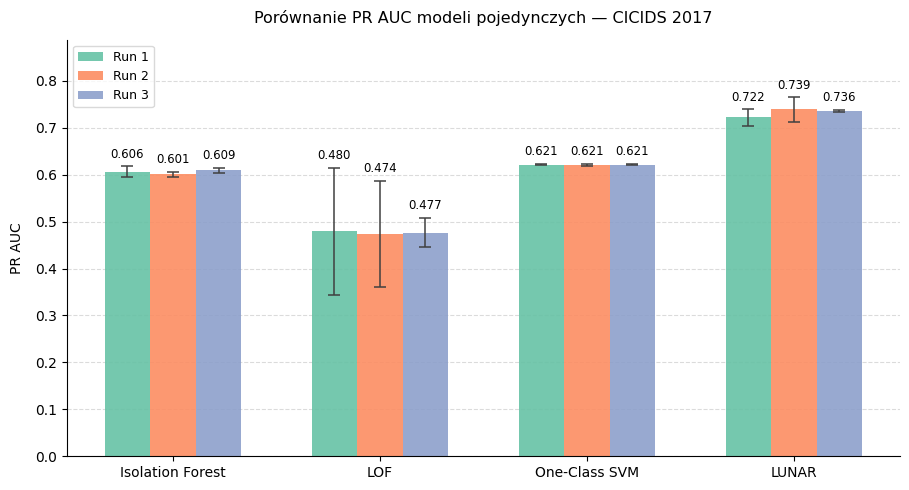

Zapisano: figsolo-prauc-final-unsw.pdf oraz figsolo-prauc-final-unsw.png


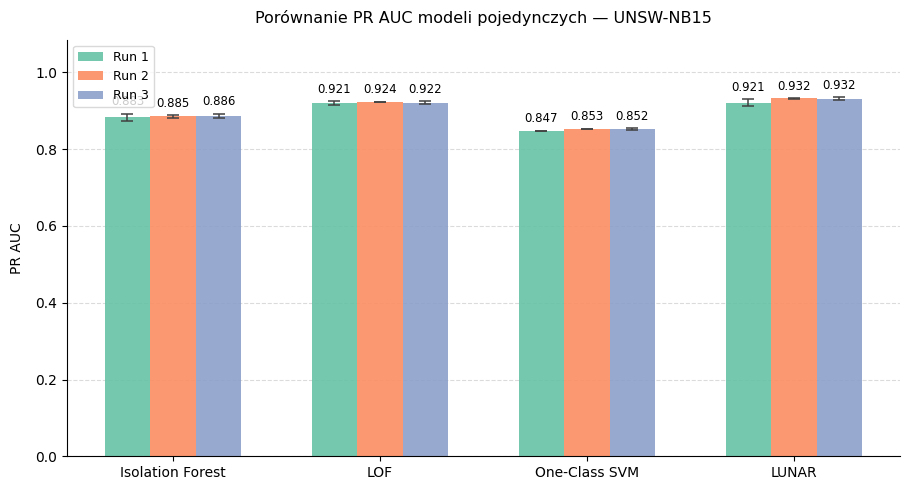

In [30]:
bar_per_dataset(SOLO, 'AUC_PR', 'figsolo-prauc-final', 'PR AUC', 'Porównanie PR AUC modeli pojedynczych')


# Wykres: FP/FN modeli pojedynczych (figsolo-fpfn-ds)

Zapisano: figsolo-fpfn-cicids.pdf oraz figsolo-fpfn-cicids.png


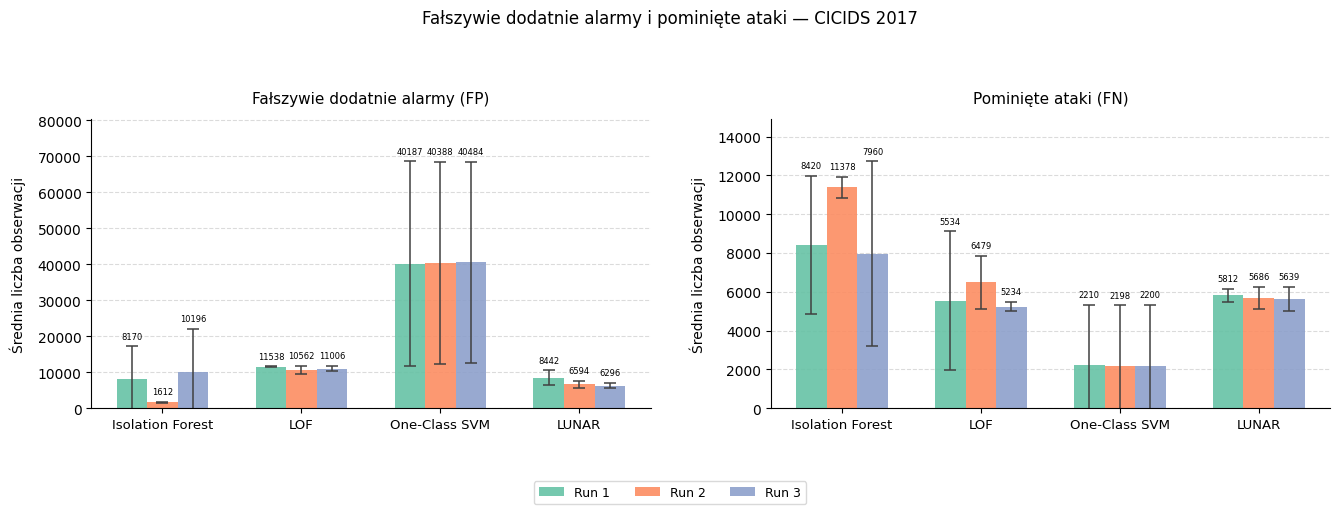

Zapisano: figsolo-fpfn-unsw.pdf oraz figsolo-fpfn-unsw.png


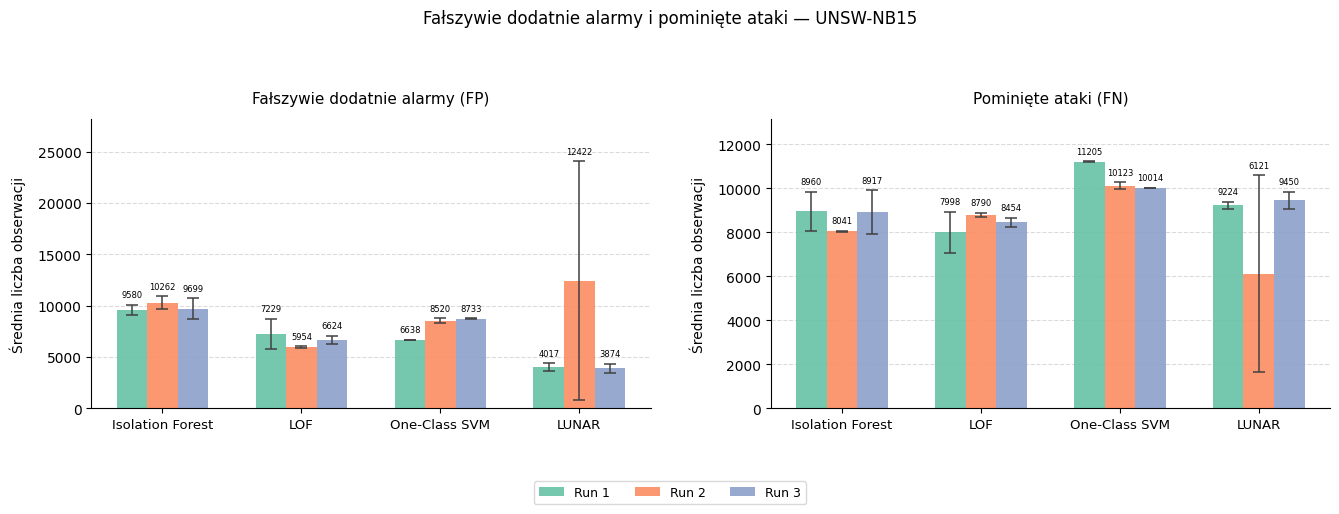

In [34]:
def bar_fp_fn_per_dataset(
    specs,
    stem='figsolo-fpfn',
    source=None,
    run_indices=(1, 2, 3),
):
    
    if source is None:
        source = df_std_clean

    required_columns = {
        'dataset_name',
        'model_type',
        'fusion_strategy',
        'seed',
        'run_index',
        'ConfusionMatrix_FP',
        'ConfusionMatrix_FN',
    }

    missing_columns = required_columns - set(source.columns)

    if missing_columns:
        raise KeyError(
            'Brakuje wymaganych kolumn: '
            + ', '.join(sorted(missing_columns))
        )

    run_indices = list(run_indices)
    n_runs = len(run_indices)

    bar_width = 0.22

    offsets = (
        np.arange(n_runs) - (n_runs - 1) / 2
    ) * bar_width

    run_colors = COLORS[:n_runs]

    error_metrics = [
        ('ConfusionMatrix_FP', 'Fałszywie dodatnie alarmy (FP)'),
        ('ConfusionMatrix_FN', 'Pominięte ataki (FN)'),
    ]

    for ds in DATASETS:
        labels = [
            label
            for _, _, label in specs
        ]

        x = np.arange(len(labels))

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13.5, 4.8),
            sharex=True,
        )

        for ax, (metric, panel_title) in zip(
            axes,
            error_metrics,
        ):
            all_tops = []

            for run_position, run_index in enumerate(run_indices):
                means = []
                stds = []
                n_seeds_list = []

                for model, fusion, _ in specs:
                    sub = select(
                        source,
                        dataset=ds,
                        model=model,
                        fusion=fusion,
                    ).copy()

                    sub = sub[
                        sub['run_index'].eq(run_index)
                    ].copy()

                    if sub.empty:
                        means.append(np.nan)
                        stds.append(np.nan)
                        n_seeds_list.append(0)
                        continue

                    per_seed = (
                        sub
                        .groupby('seed')[metric]
                        .mean()
                        .dropna()
                    )

                    means.append(per_seed.mean())
                    stds.append(per_seed.std(ddof=1))
                    n_seeds_list.append(len(per_seed))

                stds_plot = [
                    0.0
                    if pd.isna(std)
                    else std
                    for std in stds
                ]

                positions = x + offsets[run_position]

                bars = ax.bar(
                    positions,
                    means,
                    width=bar_width,
                    yerr=stds_plot,
                    capsize=4,
                    color=run_colors[run_position],
                    ecolor='#404040',
                    alpha=0.90,
                    edgecolor='none',
                    error_kw={
                        'elinewidth': 1.1,
                        'capthick': 1.1,
                    },
                    label=f'Run {run_index}',
                )

                for bar, mean, std, n_seeds in zip(
                    bars,
                    means,
                    stds,
                    n_seeds_list,
                ):
                    if pd.isna(mean):
                        continue

                    std_for_label = (
                        0.0
                        if pd.isna(std)
                        else std
                    )

                    all_tops.append(mean + std_for_label)

                    ax.annotate(
                        f'{mean:.0f}',
                        xy=(
                            bar.get_x() + bar.get_width() / 2.0,
                            mean + std_for_label,
                        ),
                        xytext=(0, 4),
                        textcoords='offset points',
                        ha='center',
                        va='bottom',
                        fontsize=6,
                    )

            max_top = max(all_tops, default=1.0)

            ax.set_title(
                panel_title,
                fontsize=11,
                pad=12,
            )

            ax.set_xticks(x)

            ax.set_xticklabels(
                labels,
                rotation=0,
                fontsize=9.5,
            )

            ax.set_ylabel(
                'Średnia liczba obserwacji',
                fontsize=10,
                labelpad=8,
            )

            ax.set_ylim(0, max_top * 1.17)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.8)
            ax.spines['bottom'].set_linewidth(0.8)

            ax.yaxis.grid(
                True,
                linestyle='--',
                alpha=0.45,
                zorder=0,
            )

            ax.set_axisbelow(True)

        handles, labels_legend = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels_legend,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            frameon=True,
            facecolor='white',
            edgecolor='#D0D0D0',
            fontsize=9,
            title_fontsize=9,
        )

        fig.suptitle(
            (
                'Fałszywie dodatnie alarmy i pominięte ataki '
                f'— {DATASET_LABELS[ds]}'
            ),
            fontsize=12,
            y=0.99,
        )

        fig.tight_layout(
            rect=(0, 0.08, 1, 0.92),
            w_pad=2.8,
        )

        output_name = (
            f'{stem}-{DATASET_SUFFIX.get(ds, norm(ds))}'
        )

        savefig(fig, output_name)

        plt.show()

bar_fp_fn_per_dataset(
    SOLO,
    stem='figsolo-fpfn',
)

## 2. Self-ensemble LUNAR (bagging/boosting/stacking/voting) -- tabela


In [38]:
SELF_ENSEMBLE = [
    ('LUNAR', None, 'LUNAR pojedynczy'),
    ('LUNAR_Self_Ensemble', 'bagging', 'Bagging'),
    ('LUNAR_Self_Ensemble', 'boosting', 'Boosting'),
    ('LUNAR_Self_Ensemble', 'stacking', 'Stacking'),
    ('LUNAR_Self_Ensemble', 'voting', 'Voting'),
]


SELF_ENSEMBLE_METRICS = [
    'AUC_ROC',
    'AUC_PR',
    'Precision',
    'Recall',
    'F1',
    'runtime_train',
    'runtime_inference',
]


for ds in DATASETS:
    rows = []

    for model, fusion, label in SELF_ENSEMBLE:
        summary = run_index_seed_summary(
            df_std_clean,
            dataset=ds,
            model=model,
            fusion=fusion,
            metrics=SELF_ENSEMBLE_METRICS,
        )

        if summary.empty:
            print(
                f'UWAGA: brak wyników dla '
                f'dataset={ds}, model={model}, fusion={fusion}'
            )
            continue

        summary.insert(
            0,
            'Wariant',
            label,
        )

        rows.extend(
            summary.to_dict('records')
        )

    export_table(
        rows,
        name=f'tab_self_ensemble_{DATASET_SUFFIX[ds]}',
        caption=(
            f'Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR '
            f'dla zbioru {DATASET_LABELS[ds]} przy standardowym progu '
            f'decyzyjnym. Dla każdego numeru runu wartości podano jako '
            f'średnia $\\pm$ odchylenie standardowe między seedami '
            f'$29$ i~$81$.'
        ),
        label=f'tab:self-ensemble-{DATASET_SUFFIX[ds]}',
    )

,Wariant,Run,n seedów,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,LUNAR pojedynczy,1,2,0.859 ± 0.010,0.722 ± 0.018,0.619 ± 0.053,0.700 ± 0.017,0.656 ± 0.022,232.7 ± 56.6,9.6 ± 2.9
1,LUNAR pojedynczy,2,2,0.869 ± 0.007,0.739 ± 0.026,0.664 ± 0.042,0.696 ± 0.014,0.679 ± 0.015,138.2 ± 38.4,9.0 ± 1.9
2,LUNAR pojedynczy,3,2,0.869 ± 0.002,0.736 ± 0.003,0.670 ± 0.011,0.694 ± 0.010,0.682 ± 0.011,240.5 ± 107.2,10.0 ± 0.1
3,Bagging,1,2,0.859 ± 0.010,0.721 ± 0.019,0.615 ± 0.054,0.701 ± 0.017,0.654 ± 0.023,1230.2 ± 210.7,47.4 ± 12.3
4,Bagging,2,2,0.856 ± 0.009,0.707 ± 0.039,0.590 ± 0.067,0.698 ± 0.010,0.638 ± 0.035,699.1 ± 207.6,44.1 ± 7.2
5,Bagging,3,2,0.859 ± 0.010,0.721 ± 0.022,0.651 ± 0.006,0.650 ± 0.055,0.650 ± 0.030,1243.7 ± 532.6,53.7 ± 1.1
6,Boosting,1,2,0.859 ± 0.011,0.721 ± 0.020,0.614 ± 0.057,0.702 ± 0.020,0.653 ± 0.023,1226.7 ± 214.7,47.2 ± 12.5
7,Boosting,2,2,0.863 ± 0.005,0.724 ± 0.016,0.621 ± 0.030,0.697 ± 0.012,0.657 ± 0.012,700.8 ± 207.5,44.2 ± 7.1
8,Boosting,3,2,0.867 ± 0.001,0.734 ± 0.005,0.660 ± 0.007,0.697 ± 0.014,0.678 ± 0.010,1243.6 ± 564.1,53.0 ± 4.6
9,Stacking,1,2,0.859 ± 0.010,0.720 ± 0.020,0.621 ± 0.046,0.698 ± 0.013,0.657 ± 0.020,1258.6 ± 169.3,47.5 ± 11.9


\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR dla zbioru CICIDS 2017 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:self-ensemble-cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllccccccc}
\hline
Wariant & Run & n seedów & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
LUNAR pojedynczy & 1 & 2 & $0{,}859 \pm 0{,}010$ & $0{,}722 \pm 0{,}018$ & $0{,}619 \pm 0{,}053$ & $0{,}700 \pm 0{,}017$ & $0{,}656 \pm 0{,}022$ & $232{,}7 \pm 56{,}6$ & $9{,}6 \pm 2{,}9$ \\
LUNAR pojedynczy & 2 & 2 & $0{,}869 \pm 0{,}007$ & $0{,}739 \pm 0{,}026$ & $0{,}664 \pm 0{,}042$ & $0{,}696 \pm 0{,}014$ & $0{,}679 \pm 0{,}015$ & $138{,}2 \pm 38{,}4$ & $9{,}0 \pm 1{,}9$ \\
LUNAR pojedynczy & 3 & 2 & $0{,}869 \pm 0{,}002$ & $0{,}736 \pm 0{,}003$ & $0{,}670 \pm 0{,}011$ & $0{,}694 \pm 0{,}010$ & $0{,}682 \pm 0

,Wariant,Run,n seedów,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,LUNAR pojedynczy,1,2,0.875 ± 0.013,0.921 ± 0.009,0.897 ± 0.008,0.791 ± 0.004,0.840 ± 0.001,252.5 ± 234.0,14.1 ± 0.8
1,LUNAR pojedynczy,2,2,0.894 ± 0.001,0.932 ± 0.000,0.779 ± 0.160,0.861 ± 0.102,0.807 ± 0.043,402.4 ± 3.8,11.9 ± 0.1
2,LUNAR pojedynczy,3,2,0.894 ± 0.005,0.932 ± 0.004,0.899 ± 0.009,0.785 ± 0.009,0.839 ± 0.001,489.8 ± 264.4,13.4 ± 2.8
3,Bagging,1,2,0.872 ± 0.016,0.923 ± 0.007,0.914 ± 0.014,0.782 ± 0.004,0.843 ± 0.003,1273.3 ± 1158.9,69.2 ± 6.0
4,Bagging,2,2,0.893 ± 0.000,0.932 ± 0.000,0.880 ± 0.026,0.791 ± 0.018,0.833 ± 0.001,1850.6 ± 235.5,57.0 ± 0.5
5,Bagging,3,2,0.891 ± 0.004,0.931 ± 0.002,0.906 ± 0.016,0.778 ± 0.019,0.837 ± 0.004,2452.2 ± 1310.6,67.0 ± 14.2
6,Boosting,1,2,0.875 ± 0.013,0.924 ± 0.006,0.889 ± 0.054,0.779 ± 0.003,0.830 ± 0.022,1268.4 ± 1152.2,69.1 ± 5.6
7,Boosting,2,2,0.893 ± 0.001,0.932 ± 0.000,0.901 ± 0.004,0.776 ± 0.002,0.834 ± 0.000,1844.2 ± 206.3,56.8 ± 0.5
8,Boosting,3,2,0.890 ± 0.005,0.929 ± 0.005,0.903 ± 0.003,0.782 ± 0.008,0.838 ± 0.003,2457.5 ± 1310.9,66.9 ± 14.0
9,Stacking,1,2,0.894 ± 0.002,0.933 ± 0.001,0.910 ± 0.017,0.784 ± 0.006,0.842 ± 0.004,1269.0 ± 1153.9,69.5 ± 5.1


\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR dla zbioru UNSW-NB15 przy standardowym progu decyzyjnym. Dla każdego numeru runu wartości podano jako średnia $\pm$ odchylenie standardowe między seedami $29$ i~$81$.}
\label{tab:self-ensemble-unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllccccccc}
\hline
Wariant & Run & n seedów & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
LUNAR pojedynczy & 1 & 2 & $0{,}875 \pm 0{,}013$ & $0{,}921 \pm 0{,}009$ & $0{,}897 \pm 0{,}008$ & $0{,}791 \pm 0{,}004$ & $0{,}840 \pm 0{,}001$ & $252{,}5 \pm 234{,}0$ & $14{,}1 \pm 0{,}8$ \\
LUNAR pojedynczy & 2 & 2 & $0{,}894 \pm 0{,}001$ & $0{,}932 \pm 0{,}000$ & $0{,}779 \pm 0{,}160$ & $0{,}861 \pm 0{,}102$ & $0{,}807 \pm 0{,}043$ & $402{,}4 \pm 3{,}8$ & $11{,}9 \pm 0{,}1$ \\
LUNAR pojedynczy & 3 & 2 & $0{,}894 \pm 0{,}005$ & $0{,}932 \pm 0{,}004$ & $0{,}899 \pm 0{,}009$ & $0{,}785 \pm 0{,}009$ & $0{,}839 \pm 0{,

### Wykres: F1 self-ensemble vs LUNAR pojedynczy


Zapisano: fig_self_ensemble_f1_final.pdf oraz fig_self_ensemble_f1_final.png


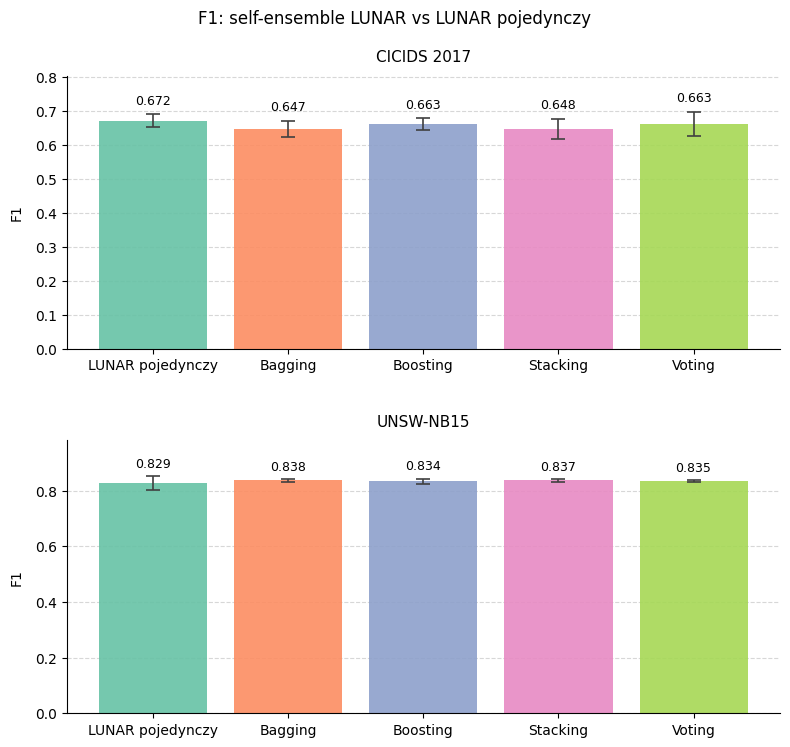

In [45]:
bar_by_dataset(SELF_ENSEMBLE, 'F1', 'fig_self_ensemble_f1_final', 'F1', 'F1: self-ensemble LUNAR vs LUNAR pojedynczy')


### Wykres: koszt uczenia/wnioskowania self-ensemble -- POMINIETY WCZESNIEJ, DODANY


Zapisano: fig_lunar_self_ensemble_runtime-cicids.pdf oraz fig_lunar_self_ensemble_runtime-cicids.png


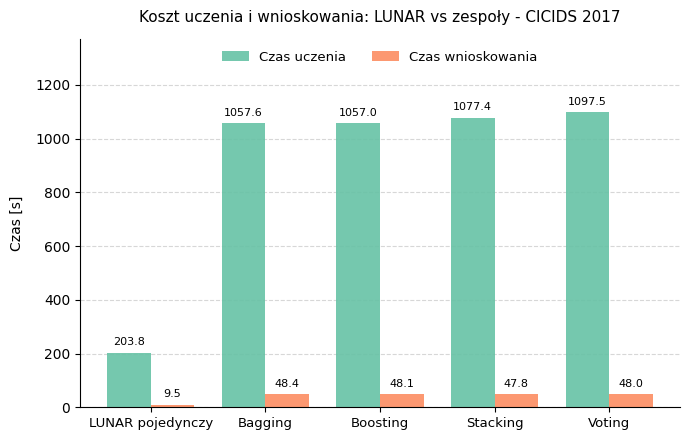

Zapisano: fig_lunar_self_ensemble_runtime-unsw.pdf oraz fig_lunar_self_ensemble_runtime-unsw.png


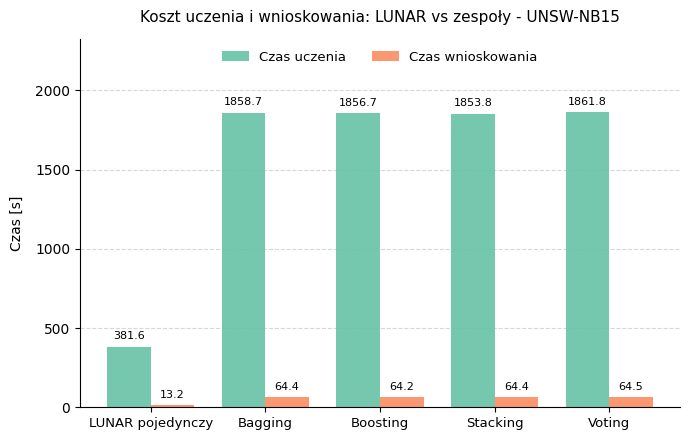

In [ ]:
# ODTWORZONE (wczesniej pominiete). Grupowany wykres: czas uczenia + czas wnioskowania.
bar_dual_metric_by_dataset(
    SELF_ENSEMBLE, ['runtime_train', 'runtime_inference'], ['Czas uczenia', 'Czas wnioskowania'],
    'fig_lunar_self_ensemble_runtime', 'Czas [s]', 'Koszt uczenia i wnioskowania: LUNAR vs zespoły'
)


## 3. Wklad LUNAR w zespole: LUNAR vs zespol klasyczny vs zespol z LUNAR -- tabela

**ODTWORZONE** i POPRAWIONE wzgledem wczesniejszej wersji: prawdziwa etykieta tabeli w oryginale to `tab_lunar_contribution_final` (nie `tab_ensemble_final` jak podalam wczesniej).


In [ ]:
CONTRIBUTION = [
    ('LUNAR', None, 'LUNAR'),
    ('Ensemble_without_LUNAR', None, 'Zespół klasyczny'),
    ('Ensemble_with_LUNAR', None, 'Zespół z LUNAR'),
]

rows = []
for ds in DATASETS:
    for model, fusion, label in CONTRIBUTION:
        sub = select(df_std_clean, ds, model, fusion)
        values = stats_for(sub)
        rows.append({
            'Zbiór': DATASET_LABELS[ds], 'Wariant': label,
            **{k: pm(*values[k]) for k in ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F1']},
            'runtime_train': pm(*values['runtime_train'], nd=1),
            'runtime_inference': pm(*values['runtime_inference'], nd=1),
        })

export_table(rows, 'tab_lunar_contribution_final',
             caption='Wkład LUNAR w zespole: porównanie LUNAR, zespołu klasycznego i zespołu z LUNAR (oba seedy: 29, 81).',
             label='tab:lunar_contribution_final')


,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR,0.866 ± 0.008,0.732 ± 0.016,0.651 ± 0.039,0.696 ± 0.011,0.672 ± 0.018,203.8 ± 76.4,9.5 ± 1.6
1,CICIDS 2017,Zespół klasyczny,0.855 ± 0.033,0.691 ± 0.046,0.617 ± 0.126,0.736 ± 0.127,0.655 ± 0.075,10.7 ± 4.5,19.2 ± 10.0
2,CICIDS 2017,Zespół z LUNAR,0.869 ± 0.022,0.720 ± 0.034,0.605 ± 0.078,0.749 ± 0.092,0.663 ± 0.048,219.0 ± 78.9,28.3 ± 10.6
3,UNSW-NB15,LUNAR,0.888 ± 0.012,0.928 ± 0.007,0.858 ± 0.095,0.812 ± 0.059,0.829 ± 0.025,381.6 ± 191.0,13.2 ± 1.7
4,UNSW-NB15,Zespół klasyczny,0.874 ± 0.002,0.910 ± 0.001,0.830 ± 0.011,0.781 ± 0.010,0.805 ± 0.003,108.1 ± 8.8,140.3 ± 9.0
5,UNSW-NB15,Zespół z LUNAR,0.890 ± 0.005,0.924 ± 0.002,0.811 ± 0.012,0.829 ± 0.018,0.819 ± 0.003,500.6 ± 189.7,158.2 ± 11.7


\begin{table}[H]
\centering
\caption{Wkład LUNAR w zespole: porównanie LUNAR, zespołu klasycznego i zespołu z LUNAR (oba seedy: 29, 81).}
\label{tab:lunar_contribution_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Zbiór & Wariant & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
CICIDS 2017 & LUNAR & $0{,}866 \pm 0{,}008$ & $0{,}732 \pm 0{,}016$ & $0{,}651 \pm 0{,}039$ & $0{,}696 \pm 0{,}011$ & $0{,}672 \pm 0{,}018$ & $203{,}8 \pm 76{,}4$ & $9{,}5 \pm 1{,}6$ \\
CICIDS 2017 & Zespół klasyczny & $0{,}855 \pm 0{,}033$ & $0{,}691 \pm 0{,}046$ & $0{,}617 \pm 0{,}126$ & $0{,}736 \pm 0{,}127$ & $0{,}655 \pm 0{,}075$ & $10{,}7 \pm 4{,}5$ & $19{,}2 \pm 10{,}0$ \\
CICIDS 2017 & Zespół z LUNAR & $0{,}869 \pm 0{,}022$ & $0{,}720 \pm 0{,}034$ & $0{,}605 \pm 0{,}078$ & $0{,}749 \pm 0{,}092$ & $0{,}663 \pm 0{,}048$ & $219{,}0 \pm 78{,}9$ & $28{,}3 \pm 10{,}6$ \\
\hline
UNSW-NB15 & LUNAR & $0{,}888 \pm 0{,}012$ & $0{,}928 \pm 0{,}007$ & $

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR,0.866 ± 0.008,0.732 ± 0.016,0.651 ± 0.039,0.696 ± 0.011,0.672 ± 0.018,203.8 ± 76.4,9.5 ± 1.6
1,CICIDS 2017,Zespół klasyczny,0.855 ± 0.033,0.691 ± 0.046,0.617 ± 0.126,0.736 ± 0.127,0.655 ± 0.075,10.7 ± 4.5,19.2 ± 10.0
2,CICIDS 2017,Zespół z LUNAR,0.869 ± 0.022,0.720 ± 0.034,0.605 ± 0.078,0.749 ± 0.092,0.663 ± 0.048,219.0 ± 78.9,28.3 ± 10.6
3,UNSW-NB15,LUNAR,0.888 ± 0.012,0.928 ± 0.007,0.858 ± 0.095,0.812 ± 0.059,0.829 ± 0.025,381.6 ± 191.0,13.2 ± 1.7
4,UNSW-NB15,Zespół klasyczny,0.874 ± 0.002,0.910 ± 0.001,0.830 ± 0.011,0.781 ± 0.010,0.805 ± 0.003,108.1 ± 8.8,140.3 ± 9.0
5,UNSW-NB15,Zespół z LUNAR,0.890 ± 0.005,0.924 ± 0.002,0.811 ± 0.012,0.829 ± 0.018,0.819 ± 0.003,500.6 ± 189.7,158.2 ± 11.7


### Wykres: PR-AUC -- wklad LUNAR w zespole


Zapisano: fig_lunar_contribution_prauc_final-cicids.pdf oraz fig_lunar_contribution_prauc_final-cicids.png


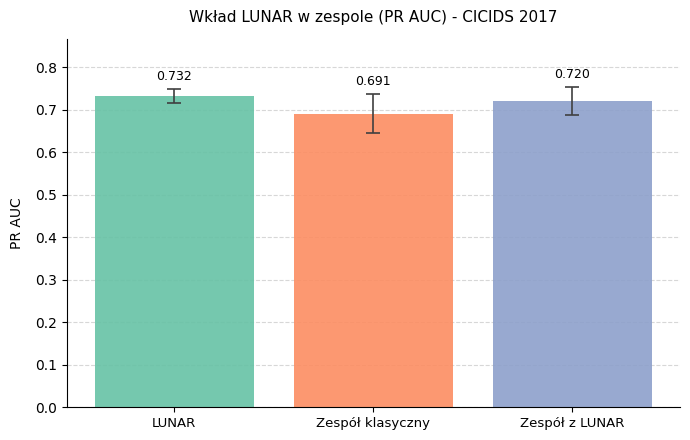

Zapisano: fig_lunar_contribution_prauc_final-unsw.pdf oraz fig_lunar_contribution_prauc_final-unsw.png


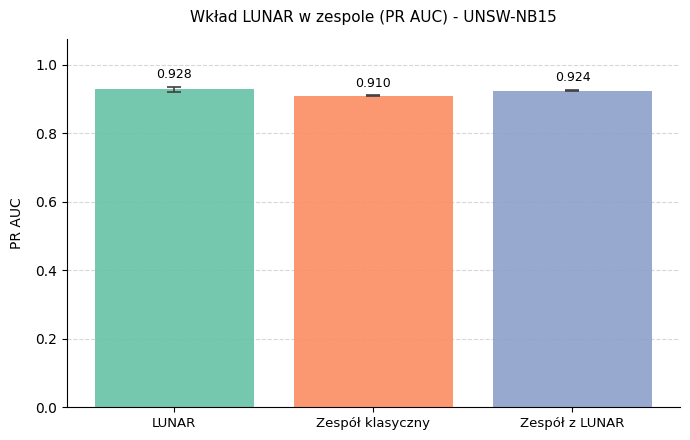

In [48]:
bar_per_dataset(CONTRIBUTION, 'AUC_PR', 'fig_lunar_contribution_prauc_final', 'PR AUC', 'Wkład LUNAR w zespole (PR AUC)')


## 3b. Modele klasyczne solo vs zespol klasyczny -- tabela i wykres (POMINIETE WCZESNIEJ, DODANE)

**ODTWORZONE.** Ten wariant NIE zawiera LUNAR-a wcale -- czysto porownanie klasycznych detektorow solo z ich zespolem.


,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Isolation Forest,0.815 ± 0.008,0.605 ± 0.007,0.705 ± 0.189,0.522 ± 0.162,0.559 ± 0.014
1,CICIDS 2017,LOF,0.802 ± 0.059,0.477 ± 0.080,0.551 ± 0.039,0.703 ± 0.094,0.617 ± 0.059
2,CICIDS 2017,One-Class SVM,0.768 ± 0.000,0.621 ± 0.001,0.333 ± 0.098,0.886 ± 0.125,0.469 ± 0.085
3,CICIDS 2017,Zespół klasyczny,0.855 ± 0.033,0.691 ± 0.046,0.617 ± 0.126,0.736 ± 0.127,0.655 ± 0.075
4,UNSW-NB15,Isolation Forest,0.843 ± 0.006,0.885 ± 0.006,0.783 ± 0.008,0.804 ± 0.017,0.793 ± 0.006
5,UNSW-NB15,LOF,0.889 ± 0.003,0.922 ± 0.003,0.844 ± 0.015,0.809 ± 0.013,0.826 ± 0.001
6,UNSW-NB15,One-Class SVM,0.818 ± 0.002,0.851 ± 0.003,0.809 ± 0.018,0.763 ± 0.013,0.785 ± 0.001
7,UNSW-NB15,Zespół klasyczny,0.874 ± 0.002,0.910 ± 0.001,0.830 ± 0.011,0.781 ± 0.010,0.805 ± 0.003


\begin{table}[H]
\centering
\caption{Modele klasyczne solo vs zespół klasyczny (bez LUNAR-a), oba seedy: 29, 81.}
\label{tab:classical_ensemble_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Zbiór & Wariant & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
CICIDS 2017 & Isolation Forest & $0{,}815 \pm 0{,}008$ & $0{,}605 \pm 0{,}007$ & $0{,}705 \pm 0{,}189$ & $0{,}522 \pm 0{,}162$ & $0{,}559 \pm 0{,}014$ \\
CICIDS 2017 & LOF & $0{,}802 \pm 0{,}059$ & $0{,}477 \pm 0{,}080$ & $0{,}551 \pm 0{,}039$ & $0{,}703 \pm 0{,}094$ & $0{,}617 \pm 0{,}059$ \\
CICIDS 2017 & One-Class SVM & $0{,}768 \pm 0{,}000$ & $0{,}621 \pm 0{,}001$ & $0{,}333 \pm 0{,}098$ & $0{,}886 \pm 0{,}125$ & $0{,}469 \pm 0{,}085$ \\
CICIDS 2017 & Zespół klasyczny & $0{,}855 \pm 0{,}033$ & $0{,}691 \pm 0{,}046$ & $0{,}617 \pm 0{,}126$ & $0{,}736 \pm 0{,}127$ & $0{,}655 \pm 0{,}075$ \\
\hline
UNSW-NB15 & Isolation Forest & $0{,}843 \pm 0{,}006$ & $0{,}885 \pm 0{,}006$ & $0{,}783 \pm 0{,}008$ & $0{,}804

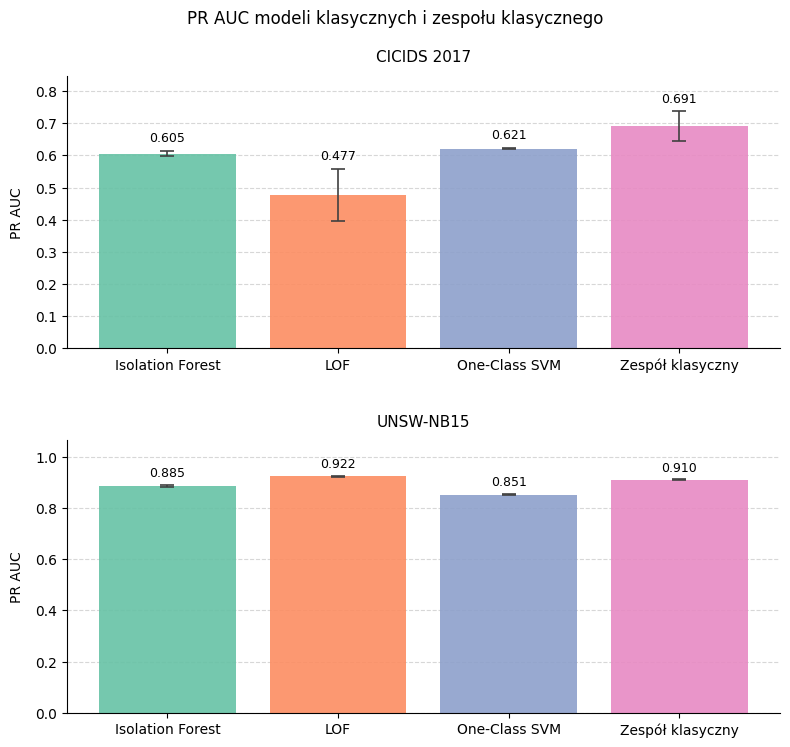

In [ ]:
CLASSICAL = [
    ('IsolationForest', None, 'Isolation Forest'),
    ('LOF', None, 'LOF'),
    ('OneClassSVM', None, 'One-Class SVM'),
    ('Ensemble_without_LUNAR', None, 'Zespół klasyczny'),
]

rows = []
for ds in DATASETS:
    for model, fusion, label in CLASSICAL:
        sub = select(df_std_clean, ds, model, fusion)
        values = stats_for(sub)
        rows.append({
            'Zbiór': DATASET_LABELS[ds], 'Wariant': label,
            **{k: pm(*values[k]) for k in ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F1']}
        })

export_table(rows, 'tab_classical_ensemble_final',
             caption='Modele klasyczne solo vs zespół klasyczny (bez LUNAR-a), oba seedy: 29, 81.',
             label='tab:classical_ensemble_final')

bar_by_dataset(CLASSICAL, 'AUC_PR', 'fig_classical_ensemble_prauc_final', 'PR AUC', 'PR AUC modeli klasycznych i zespołu klasycznego')


## 4. Porownanie poziomow fuzji (LUNAR + najlepszy baseline) -- tabela

**ODTWORZONE.** UWAGA: `Decyzja AND`/`Decyzja OR` maja wejscie binarne (0/1) -- ich AUC_ROC/AUC_PR sa liczone na zdegenerowanej, dwupunktowej krzywej. Dlatego wykres PR-AUC (nizej) POMIJA te dwa warianty -- to jest zgodne z oryginalnym notebookiem, ktory mial dokladnie taki komentarz.


In [ ]:
FUSION_LEVELS = [
    ('Fusion_Level_Comparison', 'feature_level', 'Fuzja cech'),
    ('Fusion_Level_Comparison', 'score_level', 'Fuzja wyników'),
    ('Fusion_Level_Comparison', 'decision_level_AND', 'Decyzja AND'),
    ('Fusion_Level_Comparison', 'decision_level_OR', 'Decyzja OR'),
    ('Fusion_Level_Comparison', 'feature_level_X_only', 'LR(X) - bez LUNAR'),
    ('Fusion_Level_Comparison', 'feature_level_X_plus_lunar', 'LR(X + LUNAR)'),
    ('Fusion_Level_Comparison', 'feature_level_X_plus_lunar_plus_baseline', 'LR(X + LUNAR + baseline)')
]

rows = []
for ds in DATASETS:
    for model, fusion, label in FUSION_LEVELS:
        sub = select(df_std_clean, ds, model, fusion)
        values = stats_for(sub)
        rows.append({
            'Zbiór': DATASET_LABELS[ds], 'Wariant': label,
            **{k: pm(*values[k]) for k in ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F1']}
        })

export_table(rows, 'tab_fusion_levels_final',
             caption='Porównanie poziomów fuzji: fuzja cech, fuzja wyników, decyzja AND/OR (oba seedy: 29, 81).',
             label='tab:fusion_levels_final')


,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Fuzja cech,0.960 ± 0.000,0.882 ± 0.002,0.794 ± 0.001,0.842 ± 0.010,0.817 ± 0.005
1,CICIDS 2017,Fuzja wyników,0.878 ± 0.019,0.691 ± 0.024,0.662 ± 0.059,0.772 ± 0.077,0.711 ± 0.058
2,CICIDS 2017,Decyzja AND,0.736 ± 0.034,0.516 ± 0.034,0.767 ± 0.063,0.527 ± 0.084,0.619 ± 0.048
3,CICIDS 2017,Decyzja OR,0.811 ± 0.030,0.512 ± 0.026,0.572 ± 0.028,0.819 ± 0.088,0.671 ± 0.027
4,CICIDS 2017,LR(X) - bez LUNAR,0.954 ± 0.001,0.873 ± 0.000,0.772 ± 0.004,0.864 ± 0.027,0.815 ± 0.009
5,CICIDS 2017,LR(X + LUNAR),0.960 ± 0.001,0.880 ± 0.002,0.766 ± 0.031,0.892 ± 0.055,0.823 ± 0.007
6,CICIDS 2017,LR(X + LUNAR + baseline),0.962 ± 0.004,0.886 ± 0.009,0.787 ± 0.031,0.884 ± 0.051,0.831 ± 0.020
7,UNSW-NB15,Fuzja cech,0.950 ± 0.004,0.963 ± 0.002,0.811 ± 0.003,0.923 ± 0.018,0.863 ± 0.008
8,UNSW-NB15,Fuzja wyników,0.903 ± 0.005,0.933 ± 0.002,0.826 ± 0.055,0.816 ± 0.044,0.819 ± 0.003
9,UNSW-NB15,Decyzja AND,0.831 ± 0.005,0.822 ± 0.010,0.913 ± 0.019,0.751 ± 0.014,0.824 ± 0.000


\begin{table}[H]
\centering
\caption{Porównanie poziomów fuzji: fuzja cech, fuzja wyników, decyzja AND/OR (oba seedy: 29, 81).}
\label{tab:fusion_levels_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Zbiór & Wariant & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
CICIDS 2017 & Fuzja cech & $0{,}960 \pm 0{,}000$ & $0{,}882 \pm 0{,}002$ & $0{,}794 \pm 0{,}001$ & $0{,}842 \pm 0{,}010$ & $0{,}817 \pm 0{,}005$ \\
CICIDS 2017 & Fuzja wyników & $0{,}878 \pm 0{,}019$ & $0{,}691 \pm 0{,}024$ & $0{,}662 \pm 0{,}059$ & $0{,}772 \pm 0{,}077$ & $0{,}711 \pm 0{,}058$ \\
CICIDS 2017 & Decyzja AND & $0{,}736 \pm 0{,}034$ & $0{,}516 \pm 0{,}034$ & $0{,}767 \pm 0{,}063$ & $0{,}527 \pm 0{,}084$ & $0{,}619 \pm 0{,}048$ \\
CICIDS 2017 & Decyzja OR & $0{,}811 \pm 0{,}030$ & $0{,}512 \pm 0{,}026$ & $0{,}572 \pm 0{,}028$ & $0{,}819 \pm 0{,}088$ & $0{,}671 \pm 0{,}027$ \\
CICIDS 2017 & LR(X) - bez LUNAR & $0{,}954 \pm 0{,}001$ & $0{,}873 \pm 0{,}000$ & $0{,}772 \pm 0{,}004$ & $0{,}86

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Fuzja cech,0.960 ± 0.000,0.882 ± 0.002,0.794 ± 0.001,0.842 ± 0.010,0.817 ± 0.005
1,CICIDS 2017,Fuzja wyników,0.878 ± 0.019,0.691 ± 0.024,0.662 ± 0.059,0.772 ± 0.077,0.711 ± 0.058
2,CICIDS 2017,Decyzja AND,0.736 ± 0.034,0.516 ± 0.034,0.767 ± 0.063,0.527 ± 0.084,0.619 ± 0.048
3,CICIDS 2017,Decyzja OR,0.811 ± 0.030,0.512 ± 0.026,0.572 ± 0.028,0.819 ± 0.088,0.671 ± 0.027
4,CICIDS 2017,LR(X) - bez LUNAR,0.954 ± 0.001,0.873 ± 0.000,0.772 ± 0.004,0.864 ± 0.027,0.815 ± 0.009
5,CICIDS 2017,LR(X + LUNAR),0.960 ± 0.001,0.880 ± 0.002,0.766 ± 0.031,0.892 ± 0.055,0.823 ± 0.007
6,CICIDS 2017,LR(X + LUNAR + baseline),0.962 ± 0.004,0.886 ± 0.009,0.787 ± 0.031,0.884 ± 0.051,0.831 ± 0.020
7,UNSW-NB15,Fuzja cech,0.950 ± 0.004,0.963 ± 0.002,0.811 ± 0.003,0.923 ± 0.018,0.863 ± 0.008
8,UNSW-NB15,Fuzja wyników,0.903 ± 0.005,0.933 ± 0.002,0.826 ± 0.055,0.816 ± 0.044,0.819 ± 0.003
9,UNSW-NB15,Decyzja AND,0.831 ± 0.005,0.822 ± 0.010,0.913 ± 0.019,0.751 ± 0.014,0.824 ± 0.000


### Wykres: F1 dla poziomow fuzji


Zapisano: fig_fusion_levels_f1_final.pdf oraz fig_fusion_levels_f1_final.png


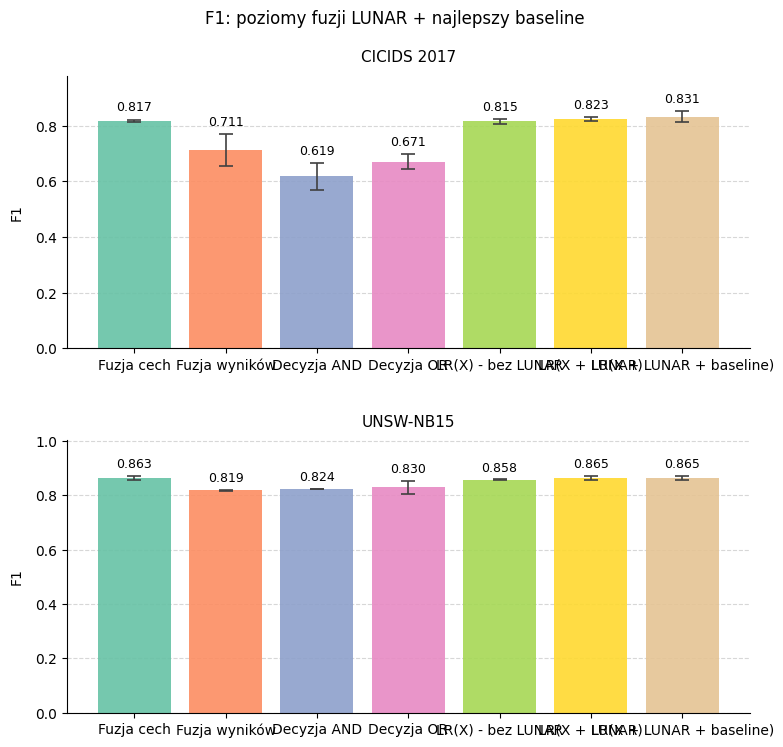

In [51]:
bar_by_dataset(FUSION_LEVELS, 'F1', 'fig_fusion_levels_f1_final', 'F1', 'F1: poziomy fuzji LUNAR + najlepszy baseline')


### Wykres: PR-AUC dla poziomow fuzji -- TYLKO warianty z ciaglym wynikiem (POPRAWKA, wczesniej pominiete)


Zapisano: fig_fusion_levels_prauc_final.pdf oraz fig_fusion_levels_prauc_final.png


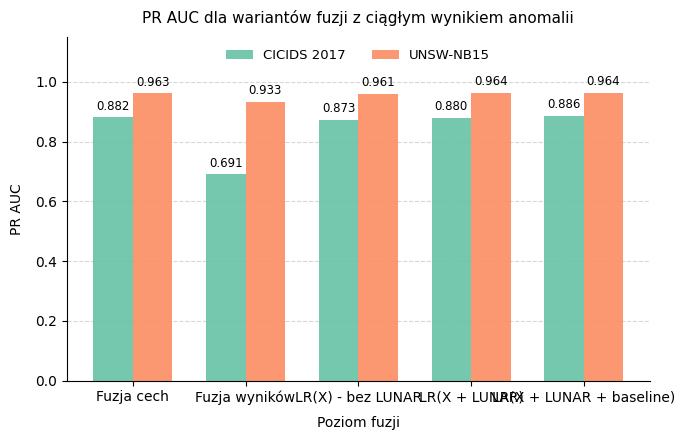

In [ ]:
# ODTWORZONE (wczesniej pominiete). Tylko fuzja cech i fuzja wynikow -- reguly
# decyzyjne AND/OR nie generuja ciaglego wyniku anomalii, wiec PR AUC nie ma
# dla nich sensu (byloby liczone z jednego punktu precyzja/czulosc, a nie z
# pelnego zakresu progow).
fusion_continuous = [s for s in FUSION_LEVELS if 'Decyzja' not in s[2]]
labels = [s[2] for s in fusion_continuous]
x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
for j, ds in enumerate(DATASETS):
    values = []
    for m, f, _ in fusion_continuous:
        sub = select(df_std_clean, ds, m, f)
        val = sub['AUC_PR'].mean() if 'AUC_PR' in sub and not sub.empty else np.nan
        values.append(val)
    rects = ax.bar(x_pos + (j - 0.5) * width, values, width, label=DATASET_LABELS[ds], color=COLORS[j], alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0, fontsize=10)
ax.set_xlabel('Poziom fuzji', fontsize=10, labelpad=8)
ax.set_ylabel('PR AUC', fontsize=10, labelpad=8)
ax.set_title('PR AUC dla wariantów fuzji z ci\u0105głym wynikiem anomalii', fontsize=11, pad=10)
ax.set_ylim(0, 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc='upper center', ncol=2, frameon=True, facecolor='white', edgecolor='none', bbox_to_anchor=(0.5, 1.0), fontsize=9.5)
fig.tight_layout()
savefig(fig, 'fig_fusion_levels_prauc_final')
plt.show()


## 5. Wrazliwosc LUNAR na liczbe epok -- tabela

**ODTWORZONE.** Zaklada kolumne `hyperparameters.n_epochs` w danych.


In [ ]:
EPOCH_COL = 'hyperparameters.n_epochs'

rows = []
for ds in DATASETS:
    sub_ds = select(df_std_clean, ds, 'LUNAR_Epochs_v2', None)
    if EPOCH_COL not in sub_ds.columns:
        print(f'UWAGA: kolumna {EPOCH_COL} nie istnieje dla {ds} - sprawdz df.columns')
        continue
    for n_epochs in sorted(sub_ds[EPOCH_COL].dropna().unique()):
        sub = sub_ds[sub_ds[EPOCH_COL] == n_epochs]
        values = stats_for(sub)
        rows.append({
            'Zbiór': DATASET_LABELS[ds], 'Liczba epok': int(n_epochs),
            'AUC_PR': pm(*values['AUC_PR']), 'F1': pm(*values['F1']),
            'runtime_train': pm(*values['runtime_train'], nd=1),
        })

export_table(rows, 'tab_epochs_final',
             caption='Wrazliwo\u015b\u0107 LUNAR na liczb\u0119 epok treningu (oba seedy: 29, 81).',
             label='tab:epochs_final')


,Zbiór,Liczba epok,AUC_PR,F1,runtime_train
0,CICIDS 2017,25,0.720 ± 0.015,0.656 ± 0.025,44.9 ± 20.9
1,CICIDS 2017,50,0.721 ± 0.014,0.657 ± 0.023,82.6 ± 40.3
2,CICIDS 2017,75,0.714 ± 0.029,0.661 ± 0.018,120.2 ± 60.0
3,CICIDS 2017,100,0.717 ± 0.023,0.661 ± 0.018,154.0 ± 74.2
4,CICIDS 2017,150,0.719 ± 0.021,0.662 ± 0.018,225.3 ± 108.0
5,CICIDS 2017,200,0.724 ± 0.025,0.669 ± 0.018,307.6 ± 133.9
6,CICIDS 2017,250,0.728 ± 0.024,0.671 ± 0.021,383.4 ± 167.4
7,CICIDS 2017,300,0.727 ± 0.027,0.671 ± 0.021,472.9 ± 220.4
8,UNSW-NB15,25,0.927 ± 0.006,0.840 ± 0.002,52.1 ± 16.9
9,UNSW-NB15,50,0.927 ± 0.007,0.840 ± 0.002,95.8 ± 32.4


\begin{table}[H]
\centering
\caption{Wrazliwość LUNAR na liczbę epok treningu (oba seedy: 29, 81).}
\label{tab:epochs_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccc}
\hline
Zbiór & Liczba epok & AUC_PR & F1 & runtime_train \\
\hline
CICIDS 2017 & 25 & $0{,}720 \pm 0{,}015$ & $0{,}656 \pm 0{,}025$ & $44{,}9 \pm 20{,}9$ \\
CICIDS 2017 & 50 & $0{,}721 \pm 0{,}014$ & $0{,}657 \pm 0{,}023$ & $82{,}6 \pm 40{,}3$ \\
CICIDS 2017 & 75 & $0{,}714 \pm 0{,}029$ & $0{,}661 \pm 0{,}018$ & $120{,}2 \pm 60{,}0$ \\
CICIDS 2017 & 100 & $0{,}717 \pm 0{,}023$ & $0{,}661 \pm 0{,}018$ & $154{,}0 \pm 74{,}2$ \\
CICIDS 2017 & 150 & $0{,}719 \pm 0{,}021$ & $0{,}662 \pm 0{,}018$ & $225{,}3 \pm 108{,}0$ \\
CICIDS 2017 & 200 & $0{,}724 \pm 0{,}025$ & $0{,}669 \pm 0{,}018$ & $307{,}6 \pm 133{,}9$ \\
CICIDS 2017 & 250 & $0{,}728 \pm 0{,}024$ & $0{,}671 \pm 0{,}021$ & $383{,}4 \pm 167{,}4$ \\
CICIDS 2017 & 300 & $0{,}727 \pm 0{,}027$ & $0{,}671 \pm 0{,}021$ & $472{,}9 \pm 220{,}4$ \\
\hline
UNSW-NB15 & 25 

,Zbiór,Liczba epok,AUC_PR,F1,runtime_train
0,CICIDS 2017,25,0.720 ± 0.015,0.656 ± 0.025,44.9 ± 20.9
1,CICIDS 2017,50,0.721 ± 0.014,0.657 ± 0.023,82.6 ± 40.3
2,CICIDS 2017,75,0.714 ± 0.029,0.661 ± 0.018,120.2 ± 60.0
3,CICIDS 2017,100,0.717 ± 0.023,0.661 ± 0.018,154.0 ± 74.2
4,CICIDS 2017,150,0.719 ± 0.021,0.662 ± 0.018,225.3 ± 108.0
5,CICIDS 2017,200,0.724 ± 0.025,0.669 ± 0.018,307.6 ± 133.9
6,CICIDS 2017,250,0.728 ± 0.024,0.671 ± 0.021,383.4 ± 167.4
7,CICIDS 2017,300,0.727 ± 0.027,0.671 ± 0.021,472.9 ± 220.4
8,UNSW-NB15,25,0.927 ± 0.006,0.840 ± 0.002,52.1 ± 16.9
9,UNSW-NB15,50,0.927 ± 0.007,0.840 ± 0.002,95.8 ± 32.4


## 6. NOWE: stabilnosc miedzy seedami (29 vs 81)

Feedback 31.08.2026 (pkt 4-5): `run_index` (1/2/3) to RóżNA wielkość próby Optuny -- NIE jest to niezależne powtórzenie. Tu grupujemy WYŁĄCZNIE po `seed`, przy ustalonym `run_index` (domyślnie 3).


In [ ]:
RUN_INDEX_COL = 'hyperparameters.run_index' if 'hyperparameters.run_index' in df_std_clean.columns else 'run_index'
FIXED_RUN_INDEX = 3

if RUN_INDEX_COL not in df_std_clean.columns:
    print(f'UWAGA: brak kolumny run_index ({RUN_INDEX_COL}) w danych - sprawdz df_std_clean.columns')
else:
    rows = []
    for ds in DATASETS:
        for model, fusion, label in SOLO:
            sub = select(df_std_clean, ds, model, fusion)
            stats = stats_for_by(sub, groupby_col='seed', fixed_col=RUN_INDEX_COL, fixed_val=FIXED_RUN_INDEX)
            row = {'Zbiór': DATASET_LABELS[ds], 'Model': label}
            for k in ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F1']:
                mean, std, n = stats[k]
                row[k] = pm_n(mean, std, n)
            rows.append(row)

    export_table(rows, 'tab_seed_stability_final',
                 caption=f'Stabilno\u015b\u0107 wyników mi\u0119dzy niezale\u017cnymi seedami (29, 81) przy run_index={FIXED_RUN_INDEX}. '
                         f'n=liczba seedow uzytych do mean+-std.',
                 label='tab:seed_stability_final')


UWAGA: brak kolumny run_index (run_index) w danych - sprawdz df_std_clean.columns


## 7. NOWE: czas treningu/inferencji modeli pojedynczych

Tabela z dokladnymi wartosciami + wykres w skali logarytmicznej (LUNAR trenuje sie rzedy wielkosci dluzej niz LOF/IF/OCSVM).


,Zbiór,Model,Czas treningu [s],Czas inferencji [s],n
0,CICIDS 2017,Isolation Forest,0.6 ± 0.1,1.3 ± 0.3,6
1,CICIDS 2017,LOF,7.8 ± 5.1,15.0 ± 9.6,6
2,CICIDS 2017,One-Class SVM,0.8 ± 0.0,1.7 ± 0.1,6
3,CICIDS 2017,LUNAR,203.8 ± 76.4,9.5 ± 1.6,6
4,UNSW-NB15,Isolation Forest,2.4 ± 0.7,5.4 ± 1.6,6
5,UNSW-NB15,LOF,30.4 ± 2.5,59.7 ± 5.0,6
6,UNSW-NB15,One-Class SVM,70.9 ± 2.2,54.6 ± 3.5,6
7,UNSW-NB15,LUNAR,381.6 ± 191.0,13.2 ± 1.7,6


\begin{table}[H]
\centering
\caption{Czas treningu i inferencji modeli pojedynczych (średnia ± odchylenie standardowe, oba seedy: 29, 81, wszystkie run_index).}
\label{tab:solo_runtime_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccc}
\hline
Zbiór & Model & Czas treningu [s] & Czas inferencji [s] & n \\
\hline
CICIDS 2017 & Isolation Forest & $0{,}6 \pm 0{,}1$ & $1{,}3 \pm 0{,}3$ & $6$ \\
CICIDS 2017 & LOF & $7{,}8 \pm 5{,}1$ & $15{,}0 \pm 9{,}6$ & $6$ \\
CICIDS 2017 & One-Class SVM & $0{,}8 \pm 0{,}0$ & $1{,}7 \pm 0{,}1$ & $6$ \\
CICIDS 2017 & LUNAR & $203{,}8 \pm 76{,}4$ & $9{,}5 \pm 1{,}6$ & $6$ \\
\hline
UNSW-NB15 & Isolation Forest & $2{,}4 \pm 0{,}7$ & $5{,}4 \pm 1{,}6$ & $6$ \\
UNSW-NB15 & LOF & $30{,}4 \pm 2{,}5$ & $59{,}7 \pm 5{,}0$ & $6$ \\
UNSW-NB15 & One-Class SVM & $70{,}9 \pm 2{,}2$ & $54{,}6 \pm 3{,}5$ & $6$ \\
UNSW-NB15 & LUNAR & $381{,}6 \pm 191{,}0$ & $13{,}2 \pm 1{,}7$ & $6$ \\
\hline
\end{tabular}}
\end{table}

Zrodlo: opracowanie wlasne.
Zapisano: fig_solo_

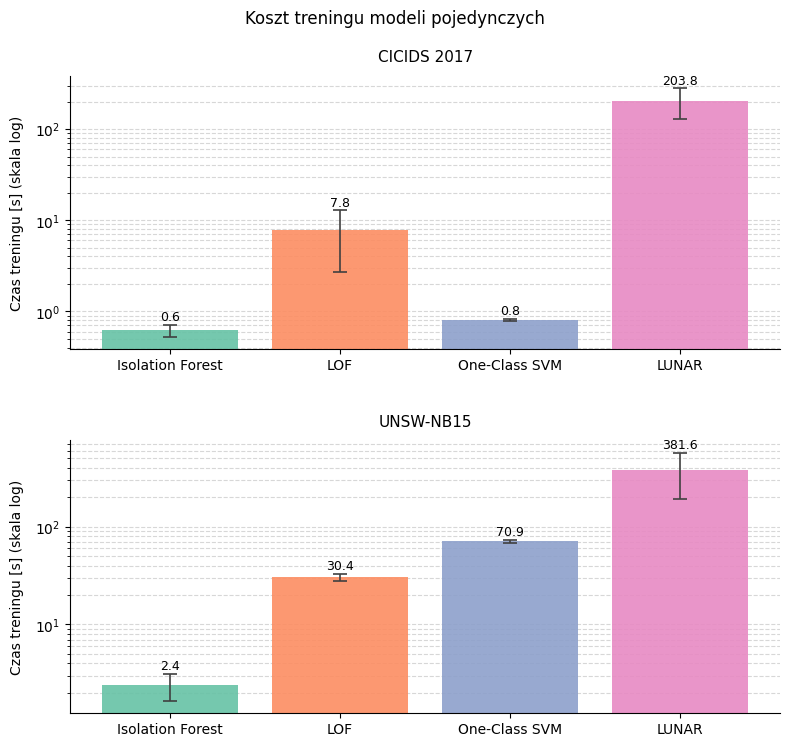

In [ ]:
rows = []
for ds in DATASETS:
    for model, fusion, label in SOLO:
        sub = select(df_std_clean, ds, model, fusion)
        values = stats_for(sub)
        rows.append({
            'Zbiór': DATASET_LABELS[ds], 'Model': label,
            'Czas treningu [s]': pm(*values['runtime_train'], nd=1),
            'Czas inferencji [s]': pm(*values['runtime_inference'], nd=1),
            'n': len(sub),
        })

export_table(rows, 'tab_solo_runtime_final',
             caption='Czas treningu i inferencji modeli pojedynczych (\u015brednia \u00b1 odchylenie standardowe, oba seedy: 29, 81, wszystkie run_index).',
             label='tab:solo_runtime_final')

bar_by_dataset(SOLO, 'runtime_train', 'fig_solo_runtime_log_final',
               'Czas treningu [s] (skala log)', 'Koszt treningu modeli pojedynczych', yscale='log')


## 8. NOWE: koszt vs jakosc -- F1 vs czas treningu

**NAPRAWIONE**: poprzednia wersja mieszala zbyt wiele nakladajacych sie etykiet w jednym miejscu na osi log. Teraz: (1) wieksza figura, (2) etykiety z alternujacym przesunieciem w gore/dol zeby sie nie nakladaly, (3) mniejsza czcionka + polprzezroczyste tlo pod etykieta, (4) punkty pogrupowane kolorem po `model_type` z legenda zamiast samych opisow w tekscie.


Zapisano: cost_vs_quality_scatter_final_cicids.pdf oraz cost_vs_quality_scatter_final_cicids.png


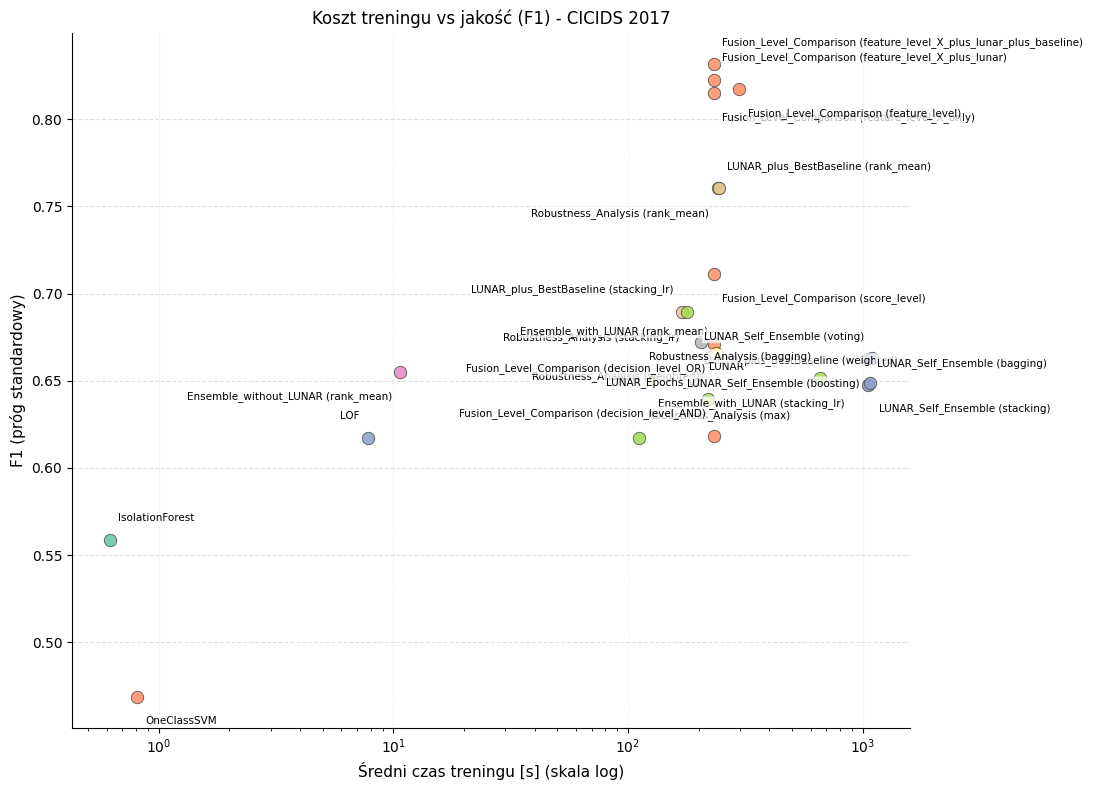

Zapisano: cost_vs_quality_scatter_final_unsw_nb15.pdf oraz cost_vs_quality_scatter_final_unsw_nb15.png


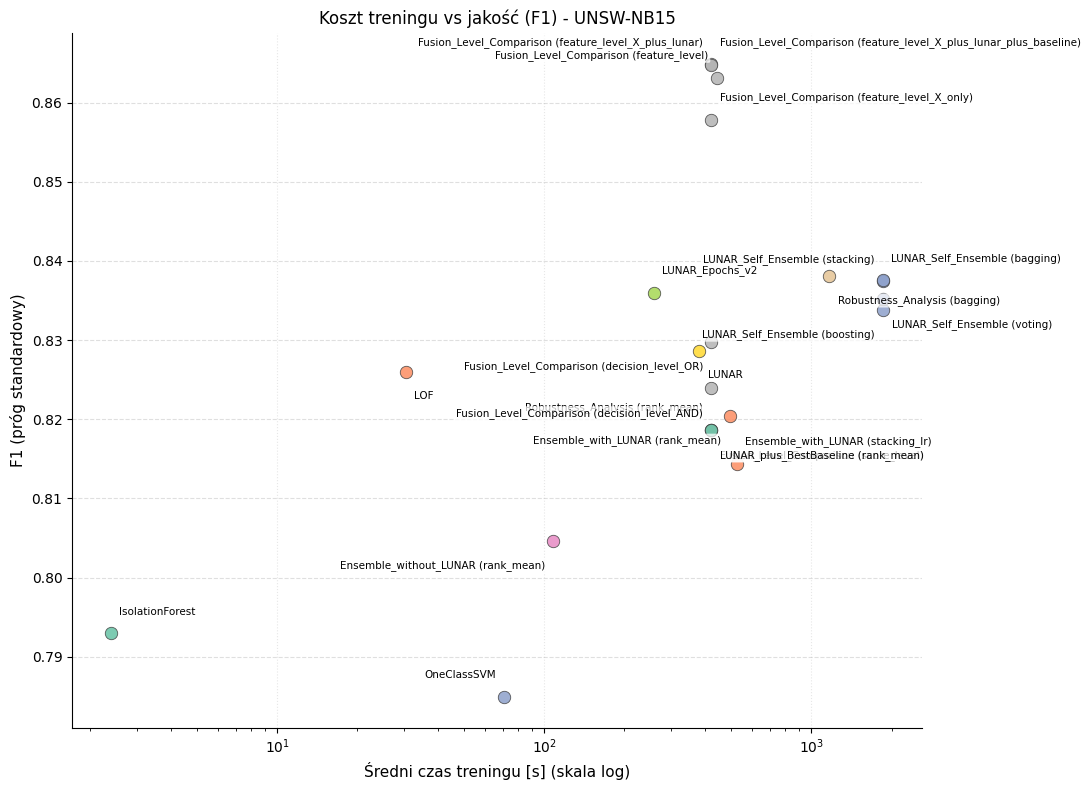

In [ ]:
def scatter_cost_vs_quality(source=None, dataset=None,
                            title='Koszt treningu vs jako\u015b\u0107 (F1)', stem='cost_vs_quality_scatter_final'):
    if source is None:
        source = df_std_clean
    sub = source if dataset is None else source[source['dataset_name'] == dataset]

    grouped = sub.groupby(['model_type', 'fusion_strategy'], dropna=False).agg(
        F1_mean=('F1', 'mean'),
        runtime_train_mean=('runtime_train', 'mean'),
    ).reset_index()
    grouped = grouped.dropna(subset=['F1_mean', 'runtime_train_mean'])
    grouped = grouped[grouped['runtime_train_mean'] > 0]
    grouped = grouped.sort_values('runtime_train_mean').reset_index(drop=True)

    # NAPRAWIONE: wieksza figura + wieksze marginesy na etykiety
    fig, ax = plt.subplots(figsize=(11, 8))
    unique_models = grouped['model_type'].unique()
    color_map = {m: COLORS[i % len(COLORS)] for i, m in enumerate(unique_models)}

    for idx, (_, row) in enumerate(grouped.iterrows()):
        ax.scatter(row['runtime_train_mean'], row['F1_mean'], s=80, alpha=0.85,
                   color=color_map[row['model_type']], edgecolor='#404040', linewidth=0.6, zorder=3)
        fusion_part = '' if pd.isna(row['fusion_strategy']) or row['fusion_strategy'] in ('none', 'None') \
            else f" ({row['fusion_strategy']})"
        label = f"{row['model_type']}{fusion_part}"

        # NAPRAWIONE: alternujace przesuniecie w gore/dol + w prawo/lewo,
        # zeby sasiadujace punkty (bliskie na osi log) nie mialy nakladajacych
        # sie etykiet. Dodatkowo polprzezroczyste biale tlo pod tekstem.
        y_offset = 12 if idx % 2 == 0 else -14
        x_offset = 6 if idx % 4 < 2 else -6
        ha = 'left' if x_offset >= 0 else 'right'
        va = 'bottom' if y_offset >= 0 else 'top'
        ax.annotate(label, (row['runtime_train_mean'], row['F1_mean']),
                    fontsize=7.5, xytext=(x_offset, y_offset), textcoords='offset points',
                    ha=ha, va=va, zorder=4,
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.75))

    ax.set_xscale('log')
    ax.set_xlabel('\u015aredni czas treningu [s] (skala log)', fontsize=11)
    ax.set_ylabel('F1 (próg standardowy)', fontsize=11)
    ax.set_title(title if dataset is None else f'{title} - {DATASET_LABELS.get(dataset, dataset)}', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.xaxis.grid(True, which='major', linestyle=':', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    savefig(fig, stem if dataset is None else f'{stem}_{dataset.lower()}')
    plt.show()
    return grouped

# Osobne wykresy per dataset (zalecane - mniej punktow nakladajacych sie na raz).
# Wykres zbiorczy (oba datasety) pomijamy domyslnie, bo przy duzej liczbie
# konfiguracji jest zbyt gesty nawet z powyzszymi poprawkami.
for _ds in DATASETS:
    _ = scatter_cost_vs_quality(dataset=_ds)
